# 量子传感仿真平台测试 — `sqc` 版本

对标 [`Simulation.ipynb`](Simulation.ipynb)，本 notebook 用重构后的 `sqc.*` API 演示各 sensing protocol。

**主要差异**：
- 顶层 API 从 `src.protocal.Protocal(type=N)` switch-case 改为独立的 `*Experiment` 类（`RabiExperiment`、`RamseyExperiment`、…）。
- 信号重建从 `Analysis.<method>()` 改为独立的 `*Reconstruction` 类。
- 所有时间轴从全局 `sqc.config.CONFIG` 派生（`dt = 1 / sample_rate`），不再用 `np.linspace`。
- 实验返回统一的 `ExperimentResult`（`.data` / `.axes` / `.metadata` / `.config`），便于序列化。

**关于兼容性**：sqc 的 `TransmonQubit` 是 `src.qubit.TransmonQubit` 的现代等价实现，构造签名一致。

## 0. 环境与全局配置

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG sample_rate = {CONFIG.awg.sample_rate} GSa/s  →  dt = {CONFIG.awg.dt} ns")
print(f"t_rabi  : start={CONFIG.pulse.t_rabi[0]:.2f}  end={CONFIG.pulse.t_rabi[-1]:.2f}  N={len(CONFIG.pulse.t_rabi)}")
print(f"t_global: start={CONFIG.pulse.t_global[0]:.2f}  end={CONFIG.pulse.t_global[-1]:.2f}  N={len(CONFIG.pulse.t_global)}")
print(f"tau_list: N={len(CONFIG.pulse.tau_list)}")
print(f"Transmon defaults: EC/h={CONFIG.transmon.EC} GHz, EJ/h={CONFIG.transmon.EJ} GHz")

AWG sample_rate = 2.0 GSa/s  →  dt = 0.5 ns
t_rabi  : start=0.00  end=9.50  N=20
t_global: start=-50.00  end=399.50  N=900
tau_list: N=500
Transmon defaults: EC/h=0.2 GHz, EJ/h=15.0 GHz


## 1. Rabi 振荡 — `RabiExperiment`

对应原 `Protocal(type=0)`。施加恒定振幅驱动脉冲，测量 $p_e(t)$。

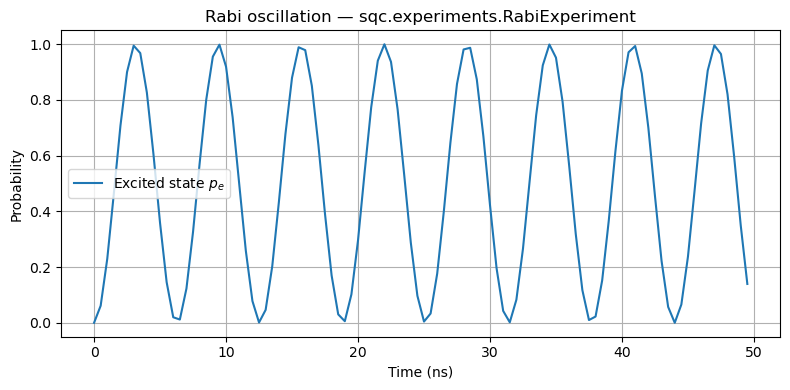

In [2]:
from sqc.experiments.rabi import RabiExperiment

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)

t_rabi = CONFIG.pulse.make_time(0, 50)  # ns
rabi_exp = RabiExperiment(qubit=qubit, t_rabi=t_rabi)
rabi_result = rabi_exp.run()

p_e = rabi_result.expect[0]

plt.figure(figsize=(8, 4))
plt.plot(t_rabi, p_e, label="Excited state $p_e$")
plt.xlabel("Time (ns)")
plt.ylabel("Probability")
plt.title("Rabi oscillation — sqc.experiments.RabiExperiment")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## 2. Ramsey 干涉 — `RamseyExperiment` + `RamseyUnwrapReconstruction`

对应原 `Protocal(type=1)`。$\pi/2$ — $\tau$ — $\pi/2$ 序列测自由演化期间积累的相位，由相位演化反推磁场 $B(t)$。

In [ ]:
from sqc.experiments.ramsey import RamseyExperiment
from sqc.reconstruction.ramsey import RamseyReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)
# 移到敏感工作点（dω/dΦ 最大处附近）
Phi_work = qubit._spec.optimal_work_point() if hasattr(qubit._spec, "optimal_work_point") else 0.25
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=Phi_work, n_levels=2,
)

ramsey_exp = RamseyExperiment(qubit=qubit)  # 用默认 sinusoidal flux
ramsey_result = ramsey_exp.run()

tau_list = ramsey_result.axes["tau"]
p_e_list = ramsey_result.data["p_e"]
B_true = ramsey_result.data["flux_samples"]

rec = RamseyReconstruction(qubit=qubit, method="unwrap")
B_rec = rec.reconstruct(ramsey_result)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tau_list, p_e_list, color="#1f77b4")
axes[0].set_xlabel(r"Delay $\tau$ (ns)"); axes[0].set_ylabel(r"$p_e$")
axes[0].set_title("Ramsey fringes"); axes[0].grid(alpha=0.3)

axes[1].plot(ramsey_result.axes["t_flux"], B_true, "k--", lw=1.4, label="Original $B$")
axes[1].plot(tau_list, B_rec, color="#e41a1c", lw=1.6, label="Reconstructed $B$")
axes[1].set_xlabel(r"$\tau$ (ns)"); axes[1].set_ylabel("$B$ (arb.)")
axes[1].set_title("Field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. 差分回波（Differential Echo）— `DiffEchoExperiment` + `DiffEchoReconstruction`

对应原 `Protocal(type=2)`。多次回波叠加增强弱信号灵敏度。

In [ ]:
from sqc.experiments.echo import DiffEchoExperiment
from sqc.reconstruction.echo import EchoReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25, n_levels=2,
)

echo_exp = DiffEchoExperiment(qubit=qubit, k=5)
echo_result = echo_exp.run()

rec = EchoReconstruction(qubit=qubit, t_int=echo_exp.t_int, k=echo_exp.k)
B_rec = rec.reconstruct(echo_result)

tau = echo_result.axes["tau"]
plt.figure(figsize=(8, 4))
plt.plot(tau, echo_result.data["flux_samples"], "k--", label="Original $B$")
plt.plot(tau, B_rec, color="#e41a1c", label="Reconstructed $B$ (DiffEcho)")
plt.xlabel(r"$\tau$ (ns)"); plt.ylabel("$B$")
plt.title(f"Differential echo (k={echo_exp.k})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 瞬态磁场感测 — `TransientSensingExperiment` + `WienerReconstruction`

对应原 `Protocal(type=4)`。滑动 Ramsey 控制脉冲扫过磁场信号，用 Wiener 反卷积从 $\Delta p$ 还原 $B(t)$。

In [ ]:
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.transient import TransientReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.9553, n_levels=2,
)

# freq
print(f"qubit frequency: {qubit.frequency}")
print(f"Optimal work point flux: {qubit.optimal_work_point()}")
trans_exp = TransientSensingExperiment(qubit=qubit)
trans_result = trans_exp.run()
kernel = trans_result.data["kernel"]

rec = TransientReconstruction(method="wiener", lambda_reg=CONFIG.reconstruction.lambda_reg)
B_rec_signal = rec.reconstruct(trans_result, kernel=trans_result.data["kernel"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trans_result.axes["scan"], trans_result.data["delta_p"], color="#1f77b4")
axes[0].set_xlabel("scan delay (ns)"); axes[0].set_ylabel(r"$\Delta p_e$")
axes[0].set_title("Sliding measurement"); axes[0].grid(alpha=0.3)

axes[1].plot(trans_result.axes["t_flux"], trans_result.data["flux_samples"], "k--", label="Original $B$")
axes[1].plot(B_rec_signal.t_list, B_rec_signal.signal, color="#e41a1c", label="Wiener reconstructed")
axes[1].set_xlabel("t (ns)"); axes[1].set_ylabel("$B$")
axes[1].set_title("Transient field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(len(kernel)), kernel, label="Kernel")
plt.xlabel("Sample Index")
plt.ylabel("Kernel Value")
plt.title("Reconstructed Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Cryoscope 完整 pipeline — 标定→测量→重建

两步 inversion 策略：
-  — 通过标定表  反查 $
-  — 通过 qubit 解析色散关系直接反演  = f_Q^{-1}(\Delta f)$

可选  对相位导数做 Savitzky-Golay 平滑（噪声数据）。

注意：
- 标定varphi的范围，np.unwrap 可能不够
- 检查IQ相位提取
- 标定波形必须在脉冲之后，不能覆盖，引入额外相位
- 目前仍然是时间轴的问题

freq=2.839 GHz, sensitivity=-6.752 GHz/Phi0
cal: kind=phi_h, h in [-0.030,0.030], phi in [60.140,-68.768] rad


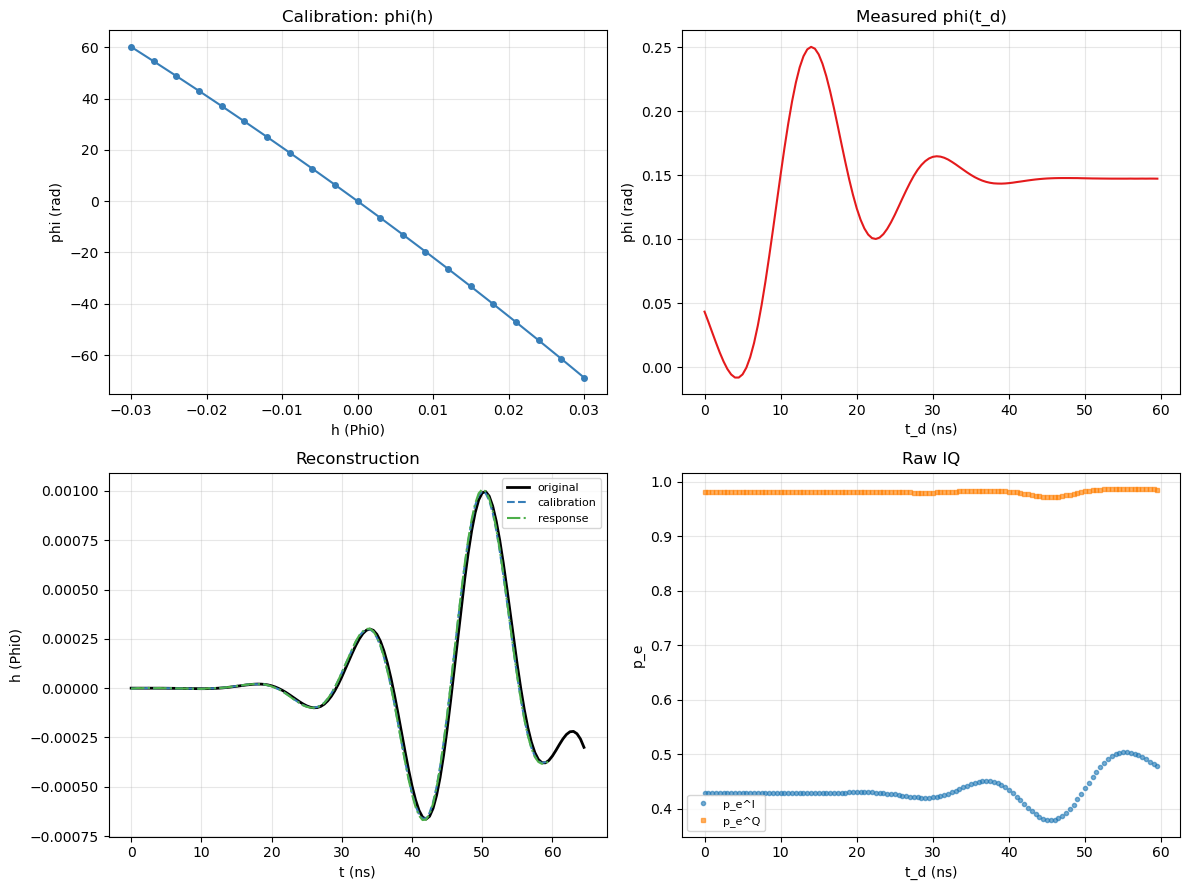

In [4]:
# === Cryoscope: 标定 → 测量 → 重建 ===
from sqc.reconstruction.cryoscope import CryoscopeCalibration
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeReconstruction

# ---- qubit（最优灵敏度工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=np.arctan(np.sqrt(2)) / np.pi,
    n_levels=3,
)

print(f"freq={qubit.frequency/(2*np.pi):.3f} GHz, sensitivity={qubit.frequency_sensitivity(qubit.flux)/(2*np.pi):.3f} GHz/Phi0")

# ---- Step 1: 标定 ----
h_list = np.linspace(-0.03, 0.03, 21)
cal = CryoscopeCalibration(qubit=qubit, h_list=h_list, tau=50.0)
cal_table = cal.calibrate()
print(f"cal: kind={cal_table.kind}, h in [{cal_table.inputs[0]:.3f},{cal_table.inputs[-1]:.3f}], phi in [{cal_table.outputs[0]:.3f},{cal_table.outputs[-1]:.3f}] rad")

# ---- Step 2: 测量 ----
trunc_list = CONFIG.pulse.make_time(0, 60)[::-1]  # ns
test_signal = FluxSignal(type=7, t_list=CONFIG.pulse.make_time(0, 65), amplitude=0.005, center=40, width=5)
cryo_exp = CryoscopeExperiment(qubit=qubit, flux_signal=test_signal, tau=50.0, trunc_list=trunc_list)
meas = cryo_exp.run()

# ---- Step 3: 重建（两种 inversion 对比）----
recon_cal = CryoscopeReconstruction(calibration=cal_table, tau=50.0, inversion="calibration")
recon_resp = CryoscopeReconstruction(qubit=qubit, tau=50.0, inversion="response")
h_cal = recon_cal.reconstruct(meas)
h_resp = recon_resp.reconstruct(meas)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0,0].plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", ms=4)
axes[0,0].set(xlabel="h (Phi0)", ylabel="phi (rad)", title="Calibration: phi(h)"); axes[0,0].grid(alpha=0.3)

trunc_inc = meas.axes["trunc"][::-1]  # axis stored decreasing
axes[0,1].plot(trunc_inc, meas.data["varphi"], color="#e41a1c")
axes[0,1].set(xlabel="t_d (ns)", ylabel="phi (rad)", title="Measured phi(t_d)"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(test_signal.t_list, test_signal.signal, "k-", lw=2, label="original")
axes[1,0].plot(h_cal.t_list, h_cal.signal, "--", color="#377eb8", label="calibration")
axes[1,0].plot(h_resp.t_list, h_resp.signal, "-.", color="#4daf4a", label="response")
axes[1,0].set(xlabel="t (ns)", ylabel="h (Phi0)", title="Reconstruction"); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(trunc_inc, meas.data["p_e_I"], "o", color="#1f77b4", ms=3, alpha=0.6, label="p_e^I")
axes[1,1].plot(trunc_inc, meas.data["p_e_Q"], "s", color="#ff7f00", ms=3, alpha=0.6, label="p_e^Q")
axes[1,1].set(xlabel="t_d (ns)", ylabel="p_e", title="Raw IQ"); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 6. 重构新增能力速览

下面这些模块在 `src/` 中不存在，是重构后新增的能力。详见 [`docs/architecture.md`](docs/architecture.md)。

### 6.1 全局配置 `sqc.config.CONFIG`
层级化配置：`awg` → `pulse` → `simulation` → `reconstruction`。所有时间轴从 `awg.dt` 派生。

### 6.2 标定层 `sqc.calibration.*`
- `FluxResponseCalibration` — f(Φ) 磁通响应标定
- `SinglePointFrequencyCalibration` — 单点频率标定 (ramsey / closed_loop)
- `WaveformCalibration` — 波形标定 (transfer_function / predistortion)
- `CalibrationScheduler` — 标定控制室

### 6.3 重建算法目录 `sqc.reconstruction.*` (按协议统一接口)
- `RamseyReconstruction(method="iq"|"unwrap")` — Ramsey 干涉协议
- `EchoReconstruction` — 差分回波协议
- `TransientReconstruction(method="wiener"|"hammerstein"|"lm")` — 瞬态感测协议
- `CryoscopeReconstruction` + `CryoscopeCalibration` — Cryoscope 协议
- `DelayRamseyReconstruction` + `DelayRamseyCalibration` — 延迟 Ramsey 协议
- `PiPulseCompReconstruction` — π脉冲补偿协议
- `KernelEstimator` / basis 工具

### 6.4 端到端工作流 `sqc.workflows.*`
- `ZCrosstalkWorkflow` — 双比特 Z-line 串扰提取与补偿端到端演示

下面给出 `ZCrosstalkWorkflow` 的最小调用框架（**不实际运行**，因为需要构造完整 `ChipTopology` + `TransferMatrix`）：

In [ ]:
# 演示 import — 实际运行参考 sqc/workflows/z_crosstalk.py 顶部 docstring
from sqc.workflows.z_crosstalk import ZCrosstalkWorkflow
from sqc.devices.chip import ChipTopology
from sqc.hardware.transfer_matrix import TransferMatrix
from sqc.control.waveform import Waveform

print("ZCrosstalkWorkflow 字段:")
for f in ZCrosstalkWorkflow.__dataclass_fields__:
    print(f"  - {f}")
print("\n要跑通需要：ChipTopology(QA, QB) + flux_pulse_on_A: Waveform + true_transfer_matrix: TransferMatrix")
print("详见 tests/regression/test_z_crosstalk_baseline.py 的完整 fixture 构造。")

## 7. Delay Ramsey — `DelayRamseyExperiment` + `DelayRamseyCalibration` + `DelayRamseyReconstruction`

**新增协议**（Track B 1.3）。在磁通敏感点处，通过滑动短 Ramsey 序列测量方波脉冲拖尾。

对应 `_sensing theory.md` §delay Ramsey。

**流程**：
1. **测量** — 施加方波 + 拖尾，在延迟 $t_d$ 处运行短 Ramsey（$\tau_R$），IQ 读相 → $\varphi(t_d)$
2. **基线** — 零磁通下重复，得到 $\varphi_{base}$，相减得 $\varphi_{tail}(t_d)$
3. **标定** — 扫描已知 $z$（flux高度），建立 $\varphi_{cal}(z) = \tau_R \cdot \kappa \cdot z$，拟合斜率 $k$
4. **重建** — $\Phi_{tail}(t_d) = \varphi_{tail}(t_d) / k$

**与 Cryoscope 对比**：Cryoscope 在甜点工作（截断瞬态抑制好但灵敏度低），Delay Ramsey 在敏感点工作（灵敏度高，适合小信号拖尾测量）。



f_q = 3.164 GHz
k = -16.8 rad/Phi0


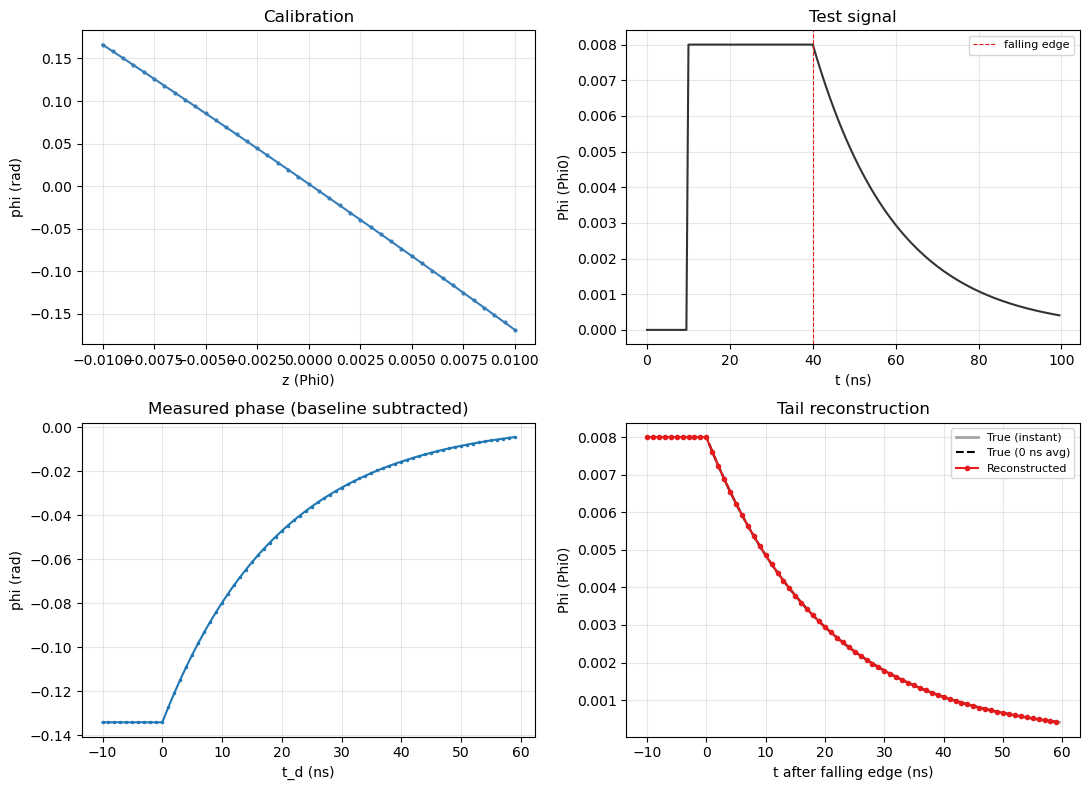

RMSE vs 0-ns moving avg = 0.000000 Phi0


In [3]:
# === Delay Ramsey: calibration + reconstruction ===
# 标定 φ_cal(z) 自动内含 τ_R 窗口平均 + Transmon 色散
# run_baseline=True 消除 arctan2(0,0) 噪声底（小拖尾时 p_I≈p_Q≈0.5）
from sqc.experiments.delay_ramsey import DelayRamseyExperiment
from sqc.reconstruction.delay_ramsey import DelayRamseyCalibration, DelayRamseyReconstruction

# ---- qubit ----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3, flux=0.25, n_levels=2,
)
print(f"f_q = {qubit.frequency/(2*np.pi):.3f} GHz")

# ---- 测试信号 ----
tau_R = 0.0
t_list = CONFIG.pulse.make_time(0, 100)
sig = np.zeros(len(t_list))
sig[(t_list >= 10) & (t_list <= 40)] = 0.008
sig[t_list > 40] = 0.008 * np.exp(-(t_list[t_list > 40] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=sig)

# ---- Step 1: 标定 ----
z_list = np.linspace(-0.010, 0.010, 41)
cal = DelayRamseyCalibration(qubit=qubit, z_list=z_list, tau_R=tau_R,
                             t_rabi=np.linspace(0, 10, 20))
cal_table = cal.calibrate()
k = cal_table.fit_params["k"]
print(f"k = {k:.1f} rad/Phi0")

# ---- Step 2: 测量 (baseline 消除 arctan2 零偏) ----
t_d_list = CONFIG.pulse.make_time(-10, 60)[::2]  # 0-59 ns, dt=1 ns
exp = DelayRamseyExperiment(qubit=qubit, flux_signal=test_flux,
                            t_d_list=t_d_list, tau_R=tau_R,
                            t_rabi=np.linspace(0, 10, 20), t_fall=40.0,
                            run_baseline=True)
meas = exp.run()

# ---- Step 3: 重建 ----
recon = DelayRamseyReconstruction(inversion="calibration", calibration=cal_table)
tail_flux = recon.reconstruct(meas)

# ---- τ_R 移动平均参考 ----
tail_avg = np.array([
    np.mean([float(test_flux.value_at(40 + td + t))
             for t in np.linspace(0, tau_R, 41)])
    for td in t_d_list
])

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
ax.plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", ms=2)
ax.set(xlabel="z (Phi0)", ylabel="phi (rad)", title="Calibration")
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_flux.t_list, test_flux.signal, color="#333333", lw=1.5)
ax.axvline(40, color="#e41a1c", ls="--", lw=0.8, label="falling edge")
ax.set(xlabel="t (ns)", ylabel="Phi (Phi0)", title="Test signal")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(meas.axes["t_d"], meas.data["varphi"], ".-", color="#1f77b4", ms=3)
ax.set(xlabel="t_d (ns)", ylabel="phi (rad)", title="Measured phase (baseline subtracted)")
ax.grid(alpha=0.3)

ax = axes[1, 1]
true_tail = sig[t_list > 40]
true_t = t_list[t_list > 40] - 40
ax.plot(true_t, true_tail, "k-", lw=2, alpha=0.35, label="True (instant)")
ax.plot(t_d_list, tail_avg, "k--", lw=1.5, label=f"True ({tau_R:.0f} ns avg)")
ax.plot(tail_flux.t_list, tail_flux.signal, "o-", color="#e41a1c", ms=3, label="Reconstructed")
ax.set(xlabel="t after falling edge (ns)", ylabel="Phi (Phi0)", title="Tail reconstruction")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

rmse = np.sqrt(np.mean((tail_flux.signal - tail_avg)**2))
print(f"RMSE vs {tau_R:.0f}-ns moving avg = {rmse:.6f} Phi0")


## 8. $\pi$ 脉冲补偿法 — `PiPulseCompensationExperiment` + `PiPulseCompReconstruction`

**新增协议**（Track B 1.4）。在磁通敏感点，用补偿脉冲 + π 脉冲的 2D 扫描测量方波拖尾。

对应 `_sensing theory.md` §$\pi$脉冲补偿法。

**流程**：
1. 施加方波，关断后存在拖尾 $\tilde{\Phi}_{sq}(t)$
2. 在延迟 $\tau$ 处施加补偿方波（宽 $T_\pi$，高 $z$）+ 同时施加 $\pi$ 脉冲
3. 若 $z$ 恰好抵消拖尾 → qubit 共振 → $P_e \to 1$
4. 2D 扫描 $(\tau, z)$ → 提取 $z^*(\tau) = \arg\max_z P_e(\tau, z)$
5. 拖尾波形 $\Phi_{tail}(\tau) \approx -z^*(\tau)$

**与 delay Ramsey 对比**：π 脉冲补偿是 2D 扫描（慢但直观），delay Ramsey 是 1D 扫描（快但需标定）。两者都在磁通敏感点工作，互补用于预失真验证。

f_q = 3.164 GHz
--- Pi-pulse compensation 2D scan ---


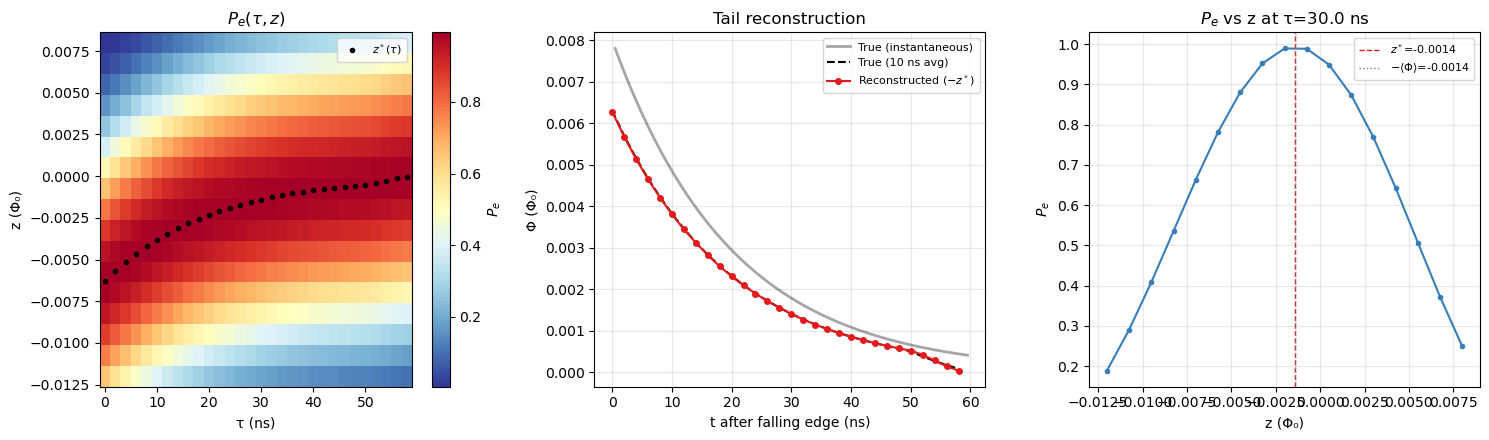

-z* vs 10-ns moving-avg tail RMSE = 0.000017 Phi0
(z_list resolution = 0.001250 Phi0)


In [2]:
# === π 脉冲补偿法：2D 扫描 → 拖尾重建 ===
from sqc.experiments.pi_pulse_comp import PiPulseCompensationExperiment
from sqc.reconstruction.pi_pulse_comp import PiPulseCompReconstruction

# ---- 初始化 qubit（磁通敏感工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25, n_levels=2,
)
omega_bias = qubit.frequency
print(f"f_q = {omega_bias/(2*np.pi):.3f} GHz")

# ---- 测试信号（与 §7 相同）----
t_list = CONFIG.pulse.make_time(0, 100)
test_signal_arr = np.zeros(len(t_list))
test_signal_arr[(t_list >= 10) & (t_list <= 40)] = 0.008
tail_mask = t_list > 40
test_signal_arr[tail_mask] = 0.008 * np.exp(-(t_list[tail_mask] - 40) / 20) #+ 0.008 * np.sin(2 * np.pi * (t_list[tail_mask] - 40) / 100)
test_flux = FluxSignal(type=8, t_list=t_list, signal=test_signal_arr)

# ---- 2D 扫描 (τ, z) ----
print("--- Pi-pulse compensation 2D scan ---")
T_pi = 10.0
tau_list = CONFIG.pulse.make_time(0, 60)[::4]  # dt=2 ns, 0-60 ns
z_list = np.linspace(-0.012, 0.008, 17)

ppc_exp = PiPulseCompensationExperiment(
    qubit=qubit, flux_signal=test_flux,
    tau_list=tau_list, z_list=z_list,
    T_pi=T_pi, omega_bias=omega_bias,
    t_rabi=np.linspace(0, 10, 20),
    t_fall=40.0,
)
result = ppc_exp.run()

# ---- 重建: Φ_tail = -z* ----
recon = PiPulseCompReconstruction()
tail_flux = recon.reconstruct(result)

# ---- 移动平均参考 (方法测量的是 [τ, τ+T_pi] 窗内的平均) ----
tail_avg = np.array([
    np.mean([float(test_flux.value_at(40.0 + tau + t))
             for t in np.linspace(0, T_pi, 21)])
    for tau in tau_list
])

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) 2D P_e(τ, z) 热力图
ax = axes[0]
Tg, Zg = np.meshgrid(tau_list, z_list, indexing="ij")
im = ax.pcolormesh(Tg, Zg, result.data["p_e"], cmap="RdYlBu_r", shading="auto")
ax.plot(tau_list, result.data["z_star"], "ko", markersize=3, label="$z^*(\\tau)$")
ax.set(xlabel="τ (ns)", ylabel="z (Φ₀)", title="$P_e(\\tau, z)$")
plt.colorbar(im, ax=ax, label="$P_e$")
ax.legend(fontsize=8)

# (b) 重建 vs 真实拖尾 (瞬时 + 移动平均)
ax = axes[1]
true_tail = test_signal_arr[t_list > 40]
true_tail_t = t_list[t_list > 40] - 40
ax.plot(true_tail_t, true_tail, "k-", lw=2, alpha=0.35, label="True (instantaneous)")
ax.plot(tau_list, tail_avg, "k--", lw=1.5, label=f"True ({T_pi:.0f} ns avg)")
ax.plot(tau_list, tail_flux.signal, "o-", color="#e41a1c", ms=4,
        label=f"Reconstructed ($-z^*$)")
ax.set(xlabel="t after falling edge (ns)", ylabel="Φ (Φ₀)", title="Tail reconstruction")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) 某个 τ 的 P_e(z) 截面
ax = axes[2]
mid_idx = len(tau_list) // 2
ax.plot(z_list, result.data["p_e"][mid_idx], "o-", color="#377eb8", markersize=3)
ax.axvline(x=result.data["z_star"][mid_idx], color="#e41a1c", ls="--", lw=1,
           label=f"$z^*$={result.data['z_star'][mid_idx]:+.4f}")
ax.axvline(x=-tail_avg[mid_idx], color="gray", ls=":", lw=1,
           label=f"$-\\langle\\Phi\\rangle$={-tail_avg[mid_idx]:+.4f}")
ax.set(xlabel="z (Φ₀)", ylabel="$P_e$", title=f"$P_e$ vs z at τ={tau_list[mid_idx]:.1f} ns")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

# ---- 定量 ----
rmse_avg = np.sqrt(np.mean((tail_flux.signal - tail_avg)**2))
print(f"-z* vs {T_pi:.0f}-ns moving-avg tail RMSE = {rmse_avg:.6f} Phi0")
print(f"(z_list resolution = {z_list[1]-z_list[0]:.6f} Phi0)")


## 9. 闭环反馈频率标定 — `SinglePointFrequencyCalibration(method="closed_loop")`

**新增能力**（对应 `_sensing theory.md` §闭环反馈控制，Vepsäläinen 2022）。

不预先标定 $f(\Phi)$ 响应曲线，而是直接迭代测量频率并调整磁通偏置 $V_n$，使 $f_Q(V_n) \to f_{target}$。

**两种频率测量方式**：
- **Ramsey FFT**：$\pi/2 - \tau - \pi/2$，扫描 $\tau$，FFT 提取失谐频率
- **Transient（核函数）**：正交 Ramsey 读出（$R_y$–$R_x$ 和 $R_y$–$R_{-x}$，$\tau=0$），$p_{diff} = (p_x - p_{-x})/2$，$\delta\omega = p_{diff}/G_\alpha$，其中 $G_\alpha = \int k(t)dt$

**两种迭代算法**：
- `step_method="secant"`（默认）：割线法 + 区间收紧（regula falsi），1-3 次迭代即可收敛
- `step_method="bisection"`：二分法，每步区间宽度减半 → 指数收敛趋势，便于可视化

下面用 **bisection** 演示完整迭代趋势。

In [8]:
# === Step 1: 创建 qubit + 粗标定 f(Φ) 给出电压 bracket ===
from sqc.calibration.frequency import FluxResponseCalibration, SinglePointFrequencyCalibration
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3, flux=0.0, n_levels=2,
)
f_bare = qubit.frequency
print(f"qubit bare frequency: {f_bare/(2*np.pi):.4f} GHz")

# ---- 粗标定 f(Φ) ----
flux_cal = FluxResponseCalibration(qubit=qubit, method="ramsey",
                                   h_list=np.linspace(-0.03, 0.03, 15), tau=100.0)
flux_table = flux_cal.calibrate()
V_a = float(np.min(flux_table.inputs))
V_b = float(np.max(flux_table.inputs))

# ---- 目标：Φ=0.025 处的频率 (~6 MHz 失谐) ----
f_interp = interp1d(flux_table.inputs, flux_table.outputs, kind="cubic")
f_target = float(f_interp(0.025))
print(f"target f(Φ=0.025) = {f_target/(2*np.pi):.6f} GHz, "
      f"detuning = {(f_target-f_bare)/(2*np.pi)*1e3:.1f} MHz")
print(f"bracket: V_a={V_a:.4f}, V_b={V_b:.4f} Φ₀")

qubit bare frequency: 3.8000 GHz
target f(Φ=0.025) = 3.806662 GHz, detuning = 6.7 MHz
bracket: V_a=-0.0300, V_b=0.0300 Φ₀


In [9]:
# === Step 2: 运行两种闭环标定（Ramsey FFT vs Transient kernel）===
# 使用 bisection 以展示 10+ 次迭代的指数收敛趋势


# ---- 方法 A: Ramsey FFT + Bisection ----
tau_long = CONFIG.pulse.make_time(0, 500)
cal_ramsey = SinglePointFrequencyCalibration(
    qubit=qubit, method="closed_loop", measure_method="ramsey",
    step_method="bisection", tau_list=tau_long, f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi, V_a=V_a, V_b=V_b, max_iter=20,
)
print("Running Ramsey FFT closed-loop...")
res_r = cal_ramsey.calibrate()
fp_r = res_r.fit_params
print(f"  iter={fp_r['n_iter']}, V_opt={fp_r['V_opt']:.6f}, "
      f"residual={abs(fp_r['residual'])/(2*np.pi)*1e3:.2f} MHz")

# ---- 方法 B: Transient kernel + Bisection ----
qubit2 = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3, flux=0.0, n_levels=2,
)
cal_transient = SinglePointFrequencyCalibration(
    qubit=qubit2, method="closed_loop", measure_method="transient",
    step_method="bisection", f_target=f_target,
    epsilon_f=1e-4 * 2 * np.pi, V_a=V_a, V_b=V_b, max_iter=20,
)
print("Running Transient kernel closed-loop...")
res_t = cal_transient.calibrate()
fp_t = res_t.fit_params
print(f"  iter={fp_t['n_iter']}, V_opt={fp_t['V_opt']:.6f}, "
      f"residual={abs(fp_t['residual'])/(2*np.pi)*1e3:.2f} MHz")

Running Ramsey FFT closed-loop...
  iter=7, V_opt=-0.026484, residual=0.00 MHz
Running Transient kernel closed-loop...
  iter=7, V_opt=-0.023672, residual=0.01 MHz


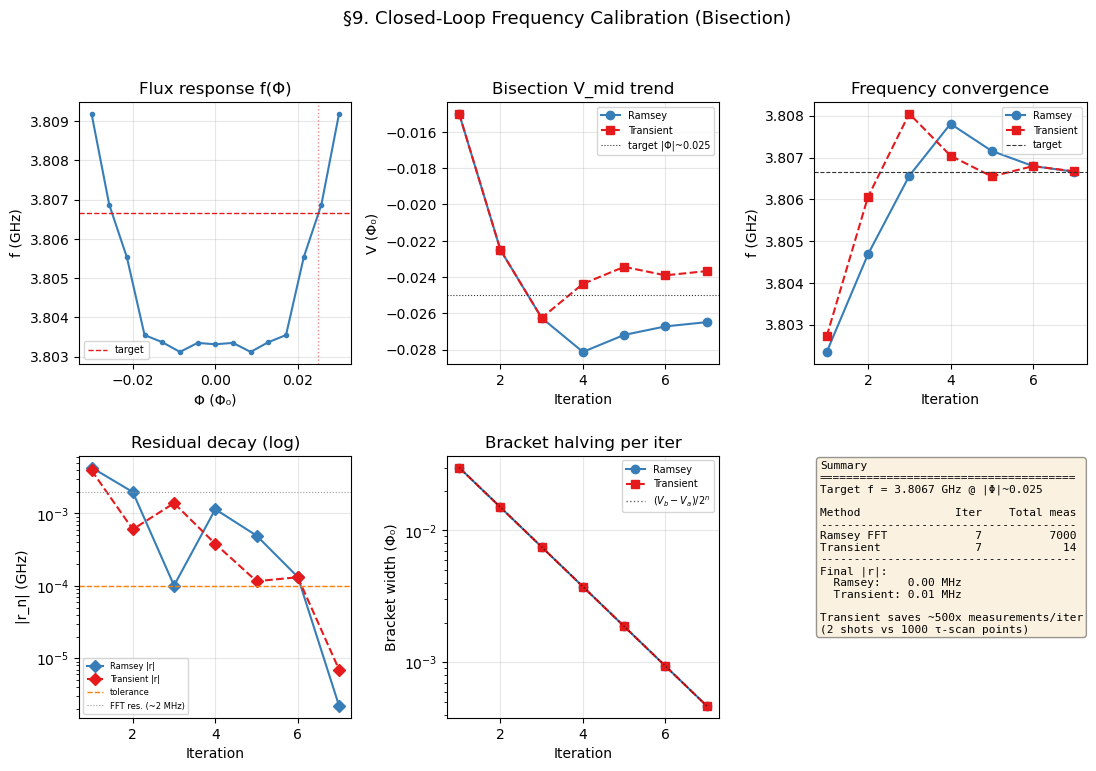


Transient kernel 每次迭代仅需 2 次单点测量，比 Ramsey FFT 快 500x。
二者精度相当，适合混合策略：transient 快速粗调 + Ramsey 精细验证。


In [10]:
# === Step 3: 收敛过程可视化 ===
hist_r = fp_r["history"]
hist_t = fp_t["history"]

fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# (a) f(Φ) 曲线 + 目标点
ax = fig.add_subplot(gs[0, 0])
ax.plot(flux_table.inputs, np.array(flux_table.outputs)/(2*np.pi), "o-", ms=3, color="#377eb8")
ax.axhline(y=f_target/(2*np.pi), color="#e41a1c", ls="--", lw=1, label="target")
ax.axvline(x=0.025, color="#e41a1c", ls=":", lw=1, alpha=0.5)
ax.set(xlabel="Φ (Φ₀)", ylabel="f (GHz)", title="Flux response f(Φ)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (b) V 收敛轨迹
ax = fig.add_subplot(gs[0, 1])
V_r = [h["V"] for h in hist_r]
V_t = [h["V"] for h in hist_t]
ax.plot(range(1, len(V_r)+1), V_r, "o-", color="#377eb8", ms=6, label="Ramsey")
ax.plot(range(1, len(V_t)+1), V_t, "s--", color="#e41a1c", ms=6, label="Transient")
ax.axhline(y=-0.025, color="#333333", ls=":", lw=0.8, label="target |Φ|~0.025")
ax.set(xlabel="Iteration", ylabel="V (Φ₀)", title="Bisection V_mid trend")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (c) 频率收敛
ax = fig.add_subplot(gs[0, 2])
f_r = [h["f"]/(2*np.pi) for h in hist_r]
f_t_v = [h["f"]/(2*np.pi) for h in hist_t]
ax.plot(range(1, len(f_r)+1), f_r, "o-", color="#377eb8", ms=6, label="Ramsey")
ax.plot(range(1, len(f_t_v)+1), f_t_v, "s--", color="#e41a1c", ms=6, label="Transient")
ax.axhline(y=f_target/(2*np.pi), color="#333333", ls="--", lw=0.8, label="target")
ax.set(xlabel="Iteration", ylabel="f (GHz)", title="Frequency convergence")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (d) 残差衰减 (log)
ax = fig.add_subplot(gs[1, 0])
r_r = np.abs([h["residual"] for h in hist_r])/(2*np.pi)
r_t = np.abs([h["residual"] for h in hist_t])/(2*np.pi)
ax.semilogy(range(1, len(r_r)+1), r_r, "D-", color="#377eb8", ms=6, label="Ramsey |r|")
ax.semilogy(range(1, len(r_t)+1), r_t, "D--", color="#e41a1c", ms=6, label="Transient |r|")
ax.axhline(y=cal_ramsey.epsilon_f/(2*np.pi), color="#ff7f00", ls="--", lw=1, label="tolerance")
ax.axhline(y=1/500, color="#999999", ls=":", lw=0.8, label="FFT res. (~2 MHz)")
ax.set(xlabel="Iteration", ylabel="|r_n| (GHz)", title="Residual decay (log)")
ax.legend(fontsize=6); ax.grid(alpha=0.3)

# (e) Bracket width 衰减 (log) — 体现二分法每步减半
ax = fig.add_subplot(gs[1, 1])
bw_r = [h.get("bracket_width", 0) for h in hist_r]
bw_t = [h.get("bracket_width", 0) for h in hist_t]
ax.semilogy(range(1, len(bw_r)+1), bw_r, "o-", color="#377eb8", ms=6, label="Ramsey")
ax.semilogy(range(1, len(bw_t)+1), bw_t, "s--", color="#e41a1c", ms=6, label="Transient")
# 理论线 width / 2^n
n = np.arange(1, max(len(bw_r), len(bw_t))+1)
ax.semilogy(n, (V_b-V_a)/(2**n), "k:", lw=1, alpha=0.6, label="$(V_b-V_a)/2^n$")
ax.set(xlabel="Iteration", ylabel="Bracket width (Φ₀)", title="Bracket halving per iter")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 总结 + 效率对比
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
n_meas_r = len(cal_ramsey.tau_list) * fp_r["n_iter"]
n_meas_t = 2 * fp_t["n_iter"]
txt = "Summary\n" + "=" * 38 + "\n"
txt += "Target f = {:.4f} GHz @ |Φ|~0.025\n\n".format(f_target/(2*np.pi))
txt += "{:<14s}{:>10s}{:>14s}\n".format("Method", "Iter", "Total meas")
txt += "-" * 38 + "\n"
txt += "{:<14s}{:>10d}{:>14d}\n".format("Ramsey FFT", fp_r["n_iter"], n_meas_r)
txt += "{:<14s}{:>10d}{:>14d}\n".format("Transient", fp_t["n_iter"], n_meas_t)
txt += "-" * 38 + "\n"
txt += "Final |r|:\n"
txt += "  Ramsey:    {:.2f} MHz\n".format(abs(fp_r["residual"])/(2*np.pi)*1e3)
txt += "  Transient: {:.2f} MHz\n".format(abs(fp_t["residual"])/(2*np.pi)*1e3)
txt += "\nTransient saves ~{}x measurements/iter\n".format(len(cal_ramsey.tau_list)//2)
txt += "(2 shots vs {} τ-scan points)".format(len(cal_ramsey.tau_list))
ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=8,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))

fig.suptitle("§9. Closed-Loop Frequency Calibration (Bisection)", fontsize=13, y=0.995)
plt.show()

print("\nTransient kernel 每次迭代仅需 2 次单点测量，比 Ramsey FFT 快 {}x。".format(
    len(cal_ramsey.tau_list)//2))
print("二者精度相当，适合混合策略：transient 快速粗调 + Ramsey 精细验证。")

# 10. 预失真全流程 — Chevron 诊断 → 阶跃响应测量 → 预失真设计 → 验证

对应 [`_sensing theory.md`](idea/_sensing theory.md) §预失真。

**理论 pipeline**：
1. **Chevron 诊断** — 检测控制线是否存在失真（Rabi/flux Chevron 图像变形）
2. **阶跃响应测量** — 施加阶跃信号 $V_{in}(t) = u(t)$，测量片上磁通 $\Phi_Q(t) = s(t)$
   - **Cryoscope**（甜点，截断 Ramsey）：相位精度高，分辨率为脉冲宽度量级
   - **瞬态磁场协议**（敏感点，滑动 Ramsey）：时间分辨率高，可达 AWG 采样率
3. **预失真设计** — $H_{inv}(\omega) = H^*(\omega) / (|H(\omega)|^2 + \lambda^2)$
4. **验证** — 施加预失真后重新测量，Chevron 恢复理想形态

**代码映射**：
| 步骤 | `sqc/` 模块 |
|------|------------|
| 失真建模 | `sqc.hardware.distortion` — `Single/MultiExponentialDistortion`, `FIR/IIRDistortion` |
| 控制线 | `sqc.hardware.control_line` — `ControlLine.apply()` / `.predistort()` |
| 阶跃响应测量 | `sqc.experiments.cryoscope` / `sqc.experiments.transient` |
| 重建算法 | `sqc.reconstruction.cryoscope` / `sqc.reconstruction.transient` |
| 预失真设计 | `sqc.calibration.waveform` — `PredistortionDesigner` |
| 端到端验证 | `sqc.workflows.predistortion_validation` — `PredistortionValidationWorkflow` |


f_01 = 3.8000 GHz, bare qubit at sweet spot
Distortion: amp=0.300, tau=30.0 ns (initial drive = 70% of nominal)


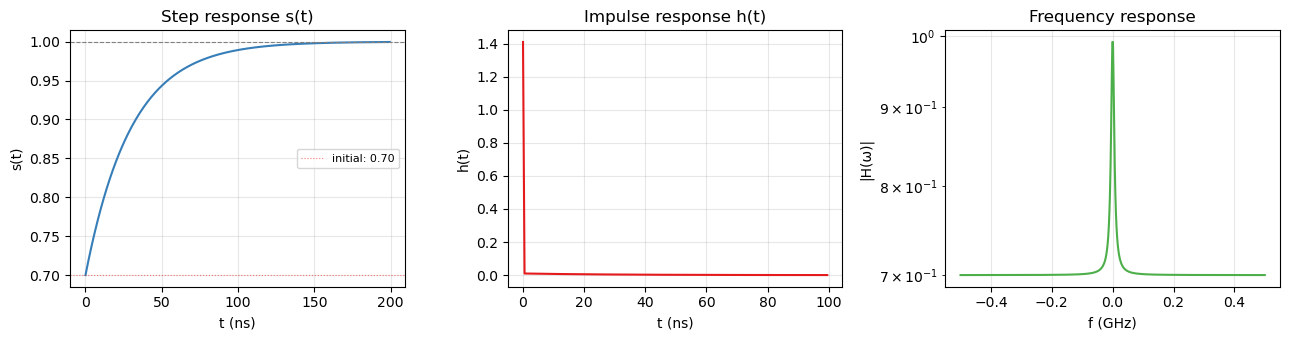

控制线就绪。


In [6]:
# === 10.0 全局设置：qubit + 失真模型 + 控制线 ===
from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal
from sqc.control.waveform import Waveform
from sqc.hardware.distortion import (
    SingleExponentialDistortion,
    MultiExponentialDistortion,
)
from sqc.hardware.control_line import ControlLine
from sqc.calibration.waveform import PredistortionDesigner, WaveformCalibration
from sqc.workflows.predistortion_validation import PredistortionValidationWorkflow

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from qutip import basis, mesolve, sigmax, sigmaz, QobjEvo

# --- qubit ---
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3, flux=0.0, n_levels=2,
)
f01 = qubit.frequency / (2 * np.pi)
print(f"f_01 = {f01:.4f} GHz, bare qubit at sweet spot")

# --- 失真模型：故意夸大以保证可视化清晰 ---
# 真实系统中 amp 通常 1-10%; 这里用 30% 让 Chevron 失真肉眼可见
dist = SingleExponentialDistortion(amplitude=0.3, tau=30.0)
print(f"Distortion: amp={dist.amplitude:.3f}, tau={dist.tau:.1f} ns "
      f"(initial drive = {1-dist.amplitude:.0%} of nominal)")

# 失真模型的阶跃响应（理论真值）
t_step = CONFIG.pulse.make_time(0, 200)
s_true = dist.step_response(t_step)

# 建立控制线
line = ControlLine(
    name="Z0", kind="z", source="AWG0:CH0", target="Q0",
    transfer_function=dist,
)

# 快速可视化失真
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(t_step, s_true, color="#377eb8")
axes[0].set(xlabel="t (ns)", ylabel="s(t)", title="Step response s(t)")
axes[0].axhline(y=1.0, color="gray", ls="--", lw=0.8)
axes[0].axhline(y=1-dist.amplitude, color="red", ls=":", lw=0.8, alpha=0.5,
                label=f"initial: {1-dist.amplitude:.2f}")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

t_h = CONFIG.pulse.make_time(0, 100)
h = dist.impulse_response(t_h)
axes[1].plot(t_h, h, color="#e41a1c")
axes[1].set(xlabel="t (ns)", ylabel="h(t)", title="Impulse response h(t)")
axes[1].grid(alpha=0.3)

omega = 2 * np.pi * np.linspace(-0.5, 0.5, 512)
H = dist.frequency_response(omega)
axes[2].semilogy(omega / (2 * np.pi), np.abs(H), color="#4daf4a")
axes[2].set(xlabel="f (GHz)", ylabel="|H(ω)|", title="Frequency response")
axes[2].grid(alpha=0.3)

fig.tight_layout(); plt.show()
print("控制线就绪。")

## 10.1 Rabi Chevron 诊断 — 检测控制线失真

Chevron 是检测控制线失真的标准初筛工具。扫描驱动频率失谐 $\Delta = \omega_d - \omega_q$ 和脉冲时长，测量 $P_e(\Delta, t)$。

- **理想**：$P_e(\Delta, t) = \frac{\Omega^2}{\Omega^2 + \Delta^2} \sin^2\left(\frac{\sqrt{\Omega^2 + \Delta^2}}{2} t\right)$，Chevron 对称、振荡清晰
- **失真**：驱动包络 $\Omega(t)$ 不再是常数方波，导致振荡模式的扭曲和衰减

下面分别展示理想（无失真）和失真后的 Chevron 图像。

Simulating distorted Chevron (41 detunings × 160 time steps)...
  detuning 10/41
  detuning 20/41
  detuning 30/41
  detuning 40/41
Done.


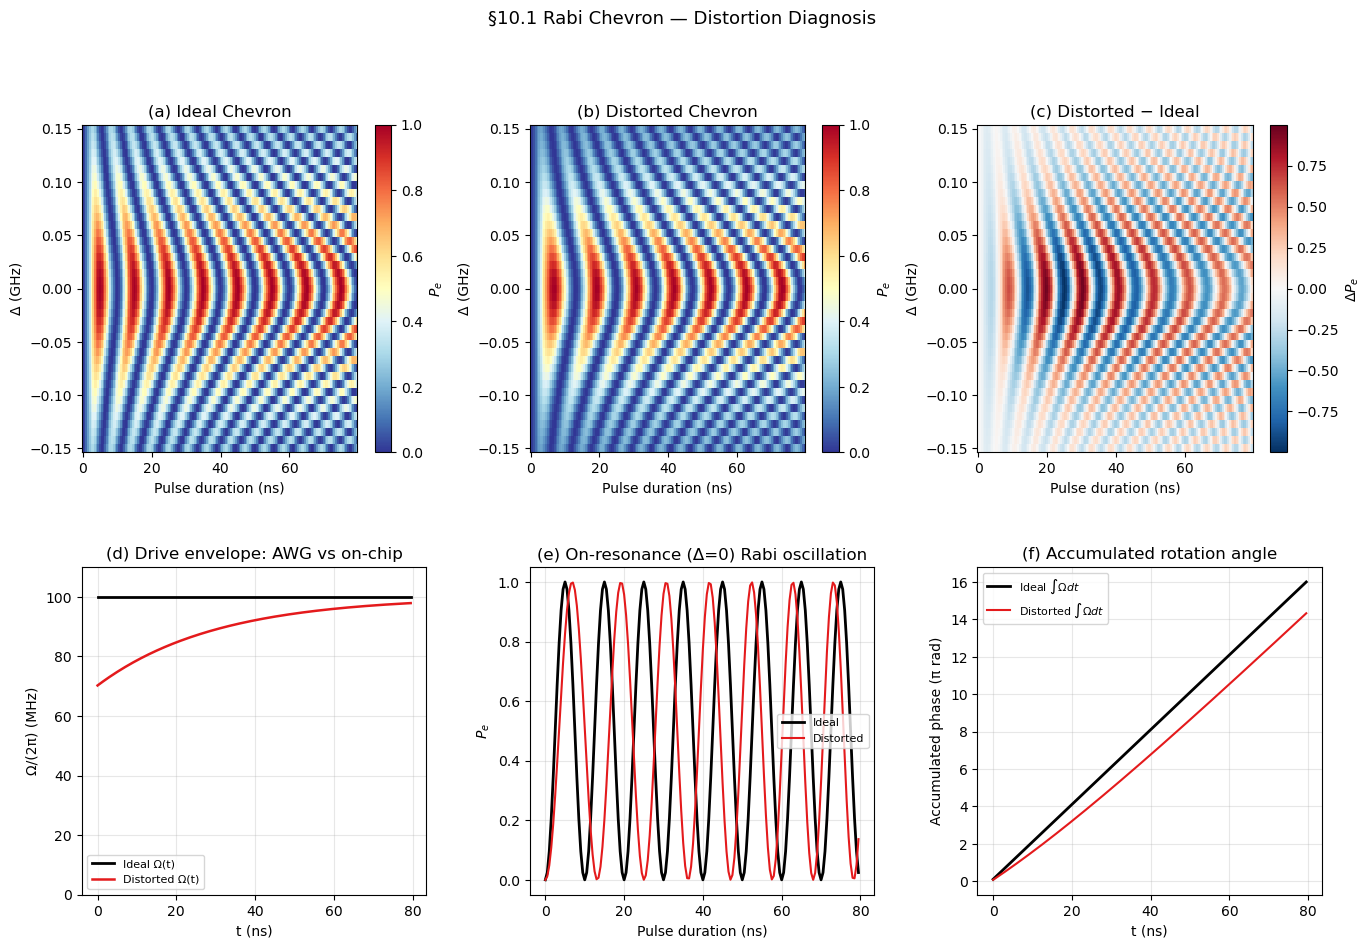


Chevron RMSE (distorted vs ideal) = 0.3813
Max |ΔP_e| = 0.9998
On-resonance peak shift: ideal first peak at t≈5.0 ns, distorted at t≈52.5 ns
→ 失真使驱动包络逐渐建立: Ω(0)=70.2 MHz, Ω(80)=97.9 MHz
→ Chevron 振荡周期从约 t≈10.0 ns（理想）变为初期更慢，导致条纹整体右移、扭曲。


In [7]:
# === 10.1 Rabi Chevron: 理想 vs 失真 ===
dt = CONFIG.awg.dt
Omega = 0.1 * 2 * np.pi  # Rabi frequency (rad·GHz)

# 扫描网格
n_det = 41
delta_list = 2 * np.pi * np.linspace(-0.15, 0.15, n_det)
t_chevron = CONFIG.pulse.make_time(0, 80)
n_t = len(t_chevron)

# ---- 理想脉冲 vs 失真脉冲包络 ----
pulse_ideal = Omega * np.ones(n_t)
pulse_distorted = dist.apply(pulse_ideal, dt)

# ---- 理想 Chevron (解析公式) ----
delta_grid, t_grid = np.meshgrid(delta_list, t_chevron, indexing="ij")
Omega_eff = np.sqrt(Omega**2 + delta_grid**2)
p_e_ideal = (Omega**2 / Omega_eff**2) * np.sin(0.5 * Omega_eff * t_grid)**2

# ---- 失真 Chevron (数值仿真) ----
print(f"Simulating distorted Chevron ({n_det} detunings × {n_t} time steps)...")
p_e_distorted = np.zeros((n_det, n_t))
psi0 = basis(2, 0)
proj_e = basis(2, 1).proj()
H1_op = 0.5 * sigmax()  # σ_x/2, coeff = Ω(t)
for i, delta in enumerate(delta_list):
    H0_op = 0.5 * delta * sigmaz()  # Δ/2 σ_z
    H = [[H0_op, np.ones(n_t)], [H1_op, pulse_distorted]]
    result = mesolve(H, psi0, t_chevron, e_ops=[proj_e])
    p_e_distorted[i, :] = result.expect[0]
    if (i + 1) % 10 == 0:
        print(f"  detuning {i+1}/{n_det}")
print("Done.")

# ============= 可视化: 6 面板布局 =============
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# (a) Ideal Chevron
ax = fig.add_subplot(gs[0, 0])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), p_e_ideal,
                    cmap="RdYlBu_r", shading="auto", vmin=0, vmax=1)
ax.set(xlabel="Pulse duration (ns)", ylabel="Δ (GHz)", title="(a) Ideal Chevron")
plt.colorbar(im, ax=ax, label="$P_e$")

# (b) Distorted Chevron
ax = fig.add_subplot(gs[0, 1])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), p_e_distorted,
                    cmap="RdYlBu_r", shading="auto", vmin=0, vmax=1)
ax.set(xlabel="Pulse duration (ns)", ylabel="Δ (GHz)", title="(b) Distorted Chevron")
plt.colorbar(im, ax=ax, label="$P_e$")

# (c) Difference: 突出失真效果
diff = p_e_distorted - p_e_ideal
vmax = max(abs(diff.min()), abs(diff.max()))
ax = fig.add_subplot(gs[0, 2])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), diff,
                    cmap="RdBu_r", shading="auto", vmin=-vmax, vmax=vmax)
ax.set(xlabel="Pulse duration (ns)", ylabel="Δ (GHz)", title="(c) Distorted − Ideal")
plt.colorbar(im, ax=ax, label="$\\Delta P_e$")

# (d) 驱动包络对比 — 解释为什么 Chevron 不同
ax = fig.add_subplot(gs[1, 0])
ax.plot(t_chevron, pulse_ideal / (2*np.pi) * 1000, "k-", lw=2, label="Ideal Ω(t)")
ax.plot(t_chevron, pulse_distorted / (2*np.pi) * 1000, color="#e41a1c", lw=1.8,
        label="Distorted Ω(t)")
ax.set(xlabel="t (ns)", ylabel="Ω/(2π) (MHz)",
       title="(d) Drive envelope: AWG vs on-chip")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(0, Omega/(2*np.pi)*1000 * 1.1)

# (e) Δ=0 共振线截面 — 最清晰的差异展示
ax = fig.add_subplot(gs[1, 1])
i_res = n_det // 2  # Δ=0
ax.plot(t_chevron, p_e_ideal[i_res], "k-", lw=2, label="Ideal")
ax.plot(t_chevron, p_e_distorted[i_res], color="#e41a1c", lw=1.5, label="Distorted")
ax.set(xlabel="Pulse duration (ns)", ylabel="$P_e$",
       title="(e) On-resonance (Δ=0) Rabi oscillation")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# (f) 累积相位对比
ax = fig.add_subplot(gs[1, 2])
phi_ideal = np.cumsum(pulse_ideal) * dt
phi_dist = np.cumsum(pulse_distorted) * dt
ax.plot(t_chevron, phi_ideal / np.pi, "k-", lw=2, label="Ideal $\\int\\Omega dt$")
ax.plot(t_chevron, phi_dist / np.pi, color="#e41a1c", lw=1.5,
        label="Distorted $\\int\\Omega dt$")
ax.set(xlabel="t (ns)", ylabel="Accumulated phase (π rad)",
       title="(f) Accumulated rotation angle")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("§10.1 Rabi Chevron — Distortion Diagnosis", fontsize=13, y=0.995)
plt.show()

# ---- 定量 ----
rmse_chevron_before = np.sqrt(np.mean(diff**2))
print(f"\nChevron RMSE (distorted vs ideal) = {rmse_chevron_before:.4f}")
print(f"Max |ΔP_e| = {np.abs(diff).max():.4f}")
print(f"On-resonance peak shift: ideal first peak at t≈{t_chevron[np.argmax(p_e_ideal[i_res])]:.1f} ns, "
      f"distorted at t≈{t_chevron[np.argmax(p_e_distorted[i_res])]:.1f} ns")
print(f"→ 失真使驱动包络逐渐建立: Ω(0)={pulse_distorted[0]/(2*np.pi)*1000:.1f} MHz, "
      f"Ω(80)={pulse_distorted[-1]/(2*np.pi)*1000:.1f} MHz")
print(f"→ Chevron 振荡周期从约 t≈{2*np.pi/Omega:.1f} ns（理想）变为初期更慢，导致条纹整体右移、扭曲。")

## 10.1bis Flux Chevron — 弯曲共振脊（flux 线失真的真正特征）

§10.1 的 Rabi Chevron 沿**驱动失谐** $\Delta = \omega_d-\omega_q$ 扫描，失真注入到驱动包络 $\Omega(t)$（即 $\sigma_x$ 系数）。但参考笔记中"弯曲共振脊"的真正物理来源是 **flux 线上的失真**——它扭曲的是 $\sigma_z$ 系数（qubit 频率 / 两能级失谐）。Rabi Chevron 沿 $\Delta$ 方向对 flux 失真天然不敏感，因此即便 $a=0.3$、$\tau=30$ ns 也只看到振荡周期变慢，看不到脊弯曲。

**Flux Chevron 配置（贴合参考图）**：
- 扫描轴：flux 幅度 $A \times$ 脉冲时长 $T$（方波幅度变化，时长变化）
- 共振条件：当片上磁通 $\Phi_Q(t)=A_{\rm res}$ 时两能级失谐为零（取 $A_{\rm res}=1.0$）
- 两能级耦合 $g$ 固定（物理来源：$|11\rangle\!\leftrightarrow\!|02\rangle$ 交换 或 qubit↔resonator 交换；此处用 2-level 简化模型）

**理想情况**：共振脊沿 $A=A_{\rm res}$ 垂直，叶状峰出现在 $T = (2n{+}1)\pi/g$。

**失真情况**：单指数失真 $s(t)=1-a\,e^{-t/\tau}$ 让片上磁通需要 $\sim\tau$ 时间才能爬升到 $A$。短脉冲下时间平均 $\langle s\rangle_T<1$，所以要让 $\langle A\,s\rangle_T = A_{\rm res}$ 必须**加大** $A$。绝热近似给出共振脊：
$$
A_{\rm res}^{\rm eff}(T) \;=\; \frac{A_{\rm res}}{\langle s\rangle_T},\qquad \langle s\rangle_T = 1 - a\,\frac{\tau}{T}\bigl(1-e^{-T/\tau}\bigr)
$$
- $T\to 0$: $A_{\rm res}^{\rm eff}\to A_{\rm res}/(1-a)$。当前 $a=0.3$ 给 $\approx 1.43$
- $T\to\infty$: $A_{\rm res}^{\rm eff}\to A_{\rm res}=1.0$

下面同时画出解析共振脊曲线和数值峰位作对照。

Simulating distorted Flux Chevron (41 amps × 300 time steps)...
  amplitude 10/41
  amplitude 20/41
  amplitude 30/41
  amplitude 40/41
Done.


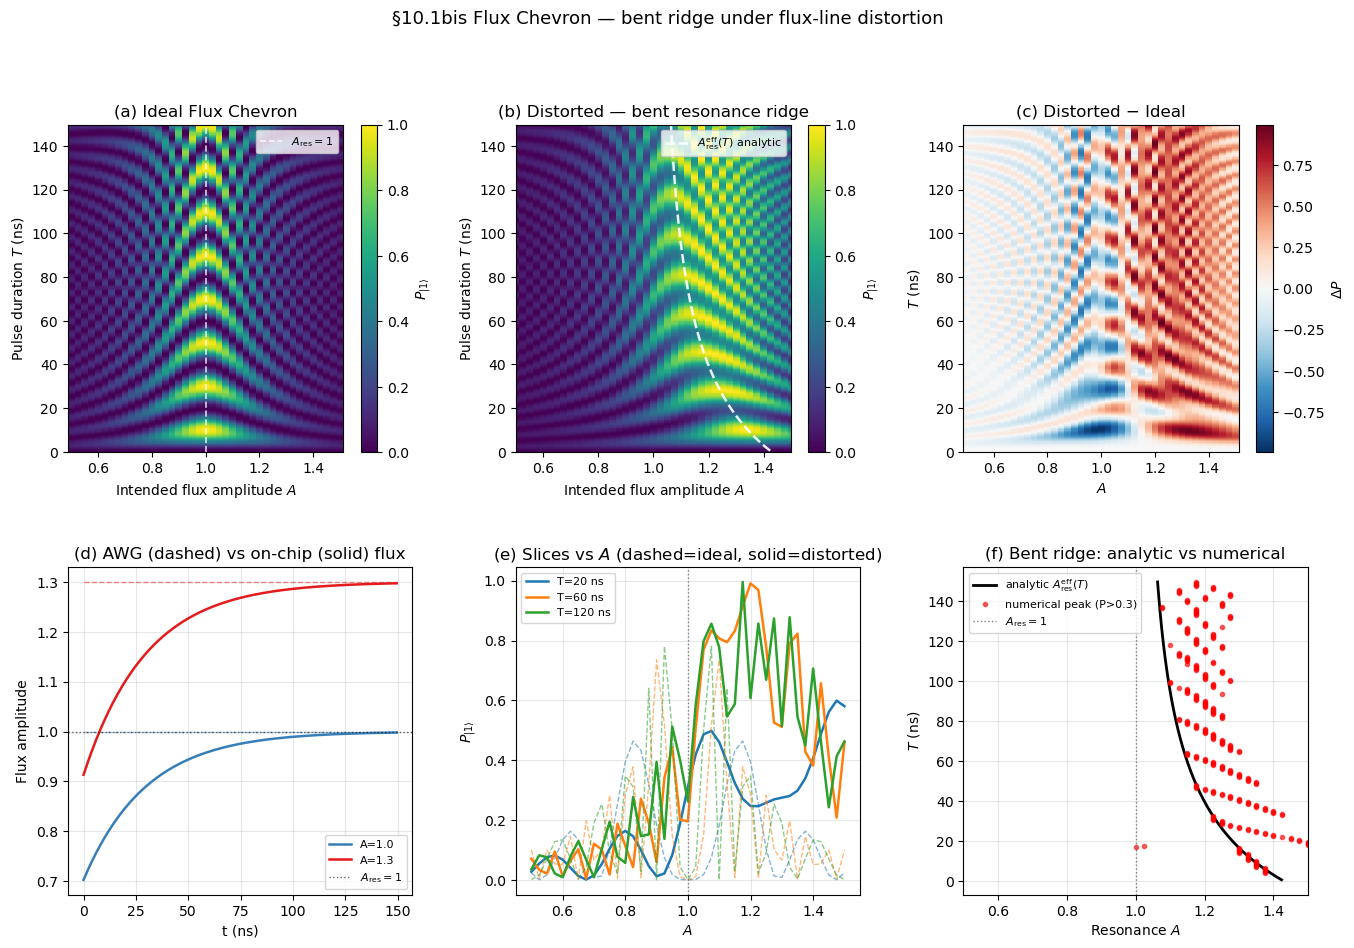


Flux Chevron RMSE (distorted vs ideal) = 0.3821
Max |ΔP| = 0.9962
短 T 极限 (T→0): A_res^eff → 1.429 = A_res/(1-a) [a=0.3]
长 T 极限 (T→∞): A_res^eff → A_res = 1.000
→ flux 线失真把共振 $A$ 从 1.00（长 T）弯曲到 1.43（短 T）。
→ 对比 §10.1 Rabi Chevron：那里沿 Δ 扫描，失真作用在 σx 通道 → 只见周期变慢，
  共振线（Δ=0）位置不动；本节沿 $A$ 扫描，失真作用在 σz 通道 → 共振脊弯曲。
  二者展示了失真注入不同 Hamiltonian 通道的不同后果，互为正交诊断。


In [8]:
# === 10.1bis Flux Chevron: 理想 vs 失真（共振脊弯曲） ===
# Two-level 模型：σz/2 系数 = κ·(A·s(t) − A_res)，σx/2 系数 = 固定耦合 g。
# 失真作用在 flux 通道（即 σz 系数随时间变化），因此短 T 时共振脊向右弯曲。
dt = CONFIG.awg.dt
g     = 0.05 * 2 * np.pi   # 两能级交换耦合 (rad·GHz)
kappa = 0.30 * 2 * np.pi   # flux → detuning 灵敏度 (rad·GHz / unit A)
A_res = 1.0                 # 共振 flux 振幅

# 扫描网格：flux 幅度 × 脉冲时长
n_A = 41
amp_list = np.linspace(0.5, 1.5, n_A)
t_flux_ch = CONFIG.pulse.make_time(0, 150)  # 加长到 150 ns 让 ridge 弯曲段可见
n_tf = len(t_flux_ch)

# ---- 理想 Flux Chevron (解析公式: detune 恒定 = κ·(A−A_res)) ----
amp_grid, t_grid = np.meshgrid(amp_list, t_flux_ch, indexing="ij")
det_ideal = kappa * (amp_grid - A_res)
g_eff = np.sqrt(g**2 + det_ideal**2)
P_ideal_flux = (g**2 / g_eff**2) * np.sin(0.5 * g_eff * t_grid)**2

# ---- 失真 Flux Chevron (数值仿真: 片上磁通 = A·s(t)) ----
print(f"Simulating distorted Flux Chevron ({n_A} amps × {n_tf} time steps)...")
P_dist_flux = np.zeros((n_A, n_tf))
psi0 = basis(2, 0); proj_e = basis(2, 1).proj()
Hg = 0.5 * g * sigmax()           # 耦合: g·σx/2 (常数)
Hz = 0.5 * sigmaz()               # σz/2, 系数随时间 = κ·(A·s(t) − A_res)
for i, A in enumerate(amp_list):
    flux_in       = A * np.ones(n_tf)
    flux_on_chip  = dist.apply(flux_in, dt)         # 失真作用在 flux 上
    det_t         = kappa * (flux_on_chip - A_res)
    H = [[Hz, det_t], [Hg, np.ones(n_tf)]]
    result = mesolve(H, psi0, t_flux_ch, e_ops=[proj_e])
    P_dist_flux[i, :] = result.expect[0]
    if (i + 1) % 10 == 0:
        print(f"  amplitude {i+1}/{n_A}")
print("Done.")

# ---- 解析弯曲共振脊曲线 A_res^eff(T) ----
a_amp, tau_d = dist.amplitude, dist.tau
T_ridge = t_flux_ch[1:]                                    # 避开 T=0
s_avg = 1.0 - a_amp * tau_d / T_ridge * (1.0 - np.exp(-T_ridge / tau_d))
A_ridge_eff = A_res / s_avg

# ============= 可视化: 6 面板布局（贴合参考图） =============
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# (a) Ideal Flux Chevron — 垂直共振脊
ax = fig.add_subplot(gs[0, 0])
im = ax.pcolormesh(amp_list, t_flux_ch, P_ideal_flux.T,
                   cmap="viridis", shading="auto", vmin=0, vmax=1)
ax.axvline(A_res, color="white", ls="--", lw=1.2, alpha=0.8,
           label="$A_{\\rm res}=1$")
ax.legend(fontsize=8, loc="upper right")
ax.set(xlabel="Intended flux amplitude $A$", ylabel="Pulse duration $T$ (ns)",
       title="(a) Ideal Flux Chevron")
plt.colorbar(im, ax=ax, label="$P_{|1\\rangle}$")

# (b) Distorted Flux Chevron — bent ridge + 解析曲线叠加
ax = fig.add_subplot(gs[0, 1])
im = ax.pcolormesh(amp_list, t_flux_ch, P_dist_flux.T,
                   cmap="viridis", shading="auto", vmin=0, vmax=1)
mask = (A_ridge_eff >= amp_list.min()) & (A_ridge_eff <= amp_list.max())
ax.plot(A_ridge_eff[mask], T_ridge[mask], "w--", lw=1.8, alpha=0.9,
        label="$A_{\\rm res}^{\\rm eff}(T)$ analytic")
ax.set_xlim(amp_list.min(), amp_list.max())
ax.legend(fontsize=8, loc="upper right")
ax.set(xlabel="Intended flux amplitude $A$", ylabel="Pulse duration $T$ (ns)",
       title="(b) Distorted — bent resonance ridge")
plt.colorbar(im, ax=ax, label="$P_{|1\\rangle}$")

# (c) Difference: 失真 − 理想
ax = fig.add_subplot(gs[0, 2])
diff_flux = P_dist_flux - P_ideal_flux
vmax = max(abs(diff_flux.min()), abs(diff_flux.max()))
im = ax.pcolormesh(amp_list, t_flux_ch, diff_flux.T,
                   cmap="RdBu_r", shading="auto", vmin=-vmax, vmax=vmax)
ax.set(xlabel="$A$", ylabel="$T$ (ns)", title="(c) Distorted − Ideal")
plt.colorbar(im, ax=ax, label="$\\Delta P$")

# (d) AWG flux vs 片上 flux: 两个代表性振幅
ax = fig.add_subplot(gs[1, 0])
for A_show, color in [(1.0, "#377eb8"), (1.3, "#e41a1c")]:
    flux_in = A_show * np.ones(n_tf)
    flux_on = dist.apply(flux_in, dt)
    ax.plot(t_flux_ch, flux_in, color=color, ls="--", lw=1.0, alpha=0.5)
    ax.plot(t_flux_ch, flux_on, color=color, lw=1.8, label=f"A={A_show}")
ax.axhline(A_res, color="black", ls=":", lw=1.0, alpha=0.6, label="$A_{\\rm res}=1$")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set(xlabel="t (ns)", ylabel="Flux amplitude",
       title="(d) AWG (dashed) vs on-chip (solid) flux")

# (e) 截面 P(A) 在固定 T: 显示峰值位置随 T 变化
ax = fig.add_subplot(gs[1, 1])
for T_show, color in [(20.0, "#1f77b4"), (60.0, "#ff7f0e"), (120.0, "#2ca02c")]:
    j = np.argmin(np.abs(t_flux_ch - T_show))
    ax.plot(amp_list, P_ideal_flux[:, j], color=color, ls="--", lw=1.0, alpha=0.55)
    ax.plot(amp_list, P_dist_flux[:, j],  color=color, lw=1.8,
            label=f"T={t_flux_ch[j]:.0f} ns")
ax.axvline(A_res, color="gray", ls=":", lw=1.0)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set(xlabel="$A$", ylabel="$P_{|1\\rangle}$",
       title="(e) Slices vs $A$ (dashed=ideal, solid=distorted)")

# (f) 弯曲共振脊曲线对比：解析 vs 数值峰位
ax = fig.add_subplot(gs[1, 2])
ax.plot(A_ridge_eff[mask], T_ridge[mask], "k-", lw=2,
        label="analytic $A_{\\rm res}^{\\rm eff}(T)$")
A_peak_num = amp_list[np.argmax(P_dist_flux, axis=0)]
# 仅保留高对比度区域以避免低 P 区域的噪声极值
peak_strength = P_dist_flux.max(axis=0)
mask_num = peak_strength > 0.3
ax.plot(A_peak_num[mask_num], t_flux_ch[mask_num], "ro", ms=3, alpha=0.6,
        label="numerical peak (P>0.3)")
ax.axvline(A_res, color="gray", ls=":", lw=1.0, label="$A_{\\rm res}=1$")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim(amp_list.min(), amp_list.max())
ax.set(xlabel="Resonance $A$", ylabel="$T$ (ns)", title="(f) Bent ridge: analytic vs numerical")

fig.suptitle("§10.1bis Flux Chevron — bent ridge under flux-line distortion",
             fontsize=13, y=0.995)
plt.show()

# ---- 定量总结 ----
rmse_flux = np.sqrt(np.mean(diff_flux**2))
A_short = A_res / (1 - a_amp)
print(f"\nFlux Chevron RMSE (distorted vs ideal) = {rmse_flux:.4f}")
print(f"Max |ΔP| = {np.abs(diff_flux).max():.4f}")
print(f"短 T 极限 (T→0): A_res^eff → {A_short:.3f} = A_res/(1-a) [a={a_amp}]")
print(f"长 T 极限 (T→∞): A_res^eff → A_res = {A_res:.3f}")
print(f"→ flux 线失真把共振 $A$ 从 {A_res:.2f}（长 T）弯曲到 {A_short:.2f}（短 T）。")
print(f"→ 对比 §10.1 Rabi Chevron：那里沿 Δ 扫描，失真作用在 σx 通道 → 只见周期变慢，")
print(f"  共振线（Δ=0）位置不动；本节沿 $A$ 扫描，失真作用在 σz 通道 → 共振脊弯曲。")
print(f"  二者展示了失真注入不同 Hamiltonian 通道的不同后果，互为正交诊断。")

## 10.2 阶跃响应测量 — 两种方法对比

Chevron 确认失真存在后，下一步是**定量测量系统的阶跃响应** $s(t) = \int_0^t h(\tau)d\tau$。

我们用一个理想阶跃信号 $V_{in}(t)$ 经失真控制线产生 $\Phi_Q(t) = s(t)$，然后用两种协议分别"测量"（重建）这个 $s(t)$，并与理论真值对比。

| | Cryoscope | 瞬态磁场协议 |
|---|---|---|
| **工作点** | 甜点 ($d\omega/d\Phi = 0$) | 最优灵敏度点 ($d\omega/d\Phi$ 最大) |
| **物理原理** | IQ Ramsey + 截断 flux 脉冲 | 滑动短 Ramsey + Wiener 反卷积 |
| **时间分辨率** | 受 $\tau_R$ 限制 (~10-50 ns) | 受 AWG dt 限制 (~0.5 ns) |
| **适用场景** | 长拖尾 ($>10$ ns)，高精度相位 | 短拖尾 ($<10$ ns)，有噪声放大 |
| **灵敏度** | 中等（甜点处二次响应） | 高（敏感点处线性响应） |

笔记推荐混合策略：Cryoscope 先粗补 IIR 长尾 → 瞬态再精补 FIR 短尾。

### 10.2.1 Cryoscope 测量阶跃响应

Cryoscope 在 qubit 甜点工作，使用 IQ Ramsey 读相。流程：标定 φ(h) → 截断 flux 脉冲测量 φ(t_d) → 反演 h(t)。

Sensitive point: flux=0.25, f=3.164 GHz, κ=-5.284 GHz/Φ₀
Step amplitude: 0.001 Φ₀ → φ_max ≈ 1.66 rad (within ±π)
Calibration: phi range [-2.404, 2.638] rad
  monotonic: True


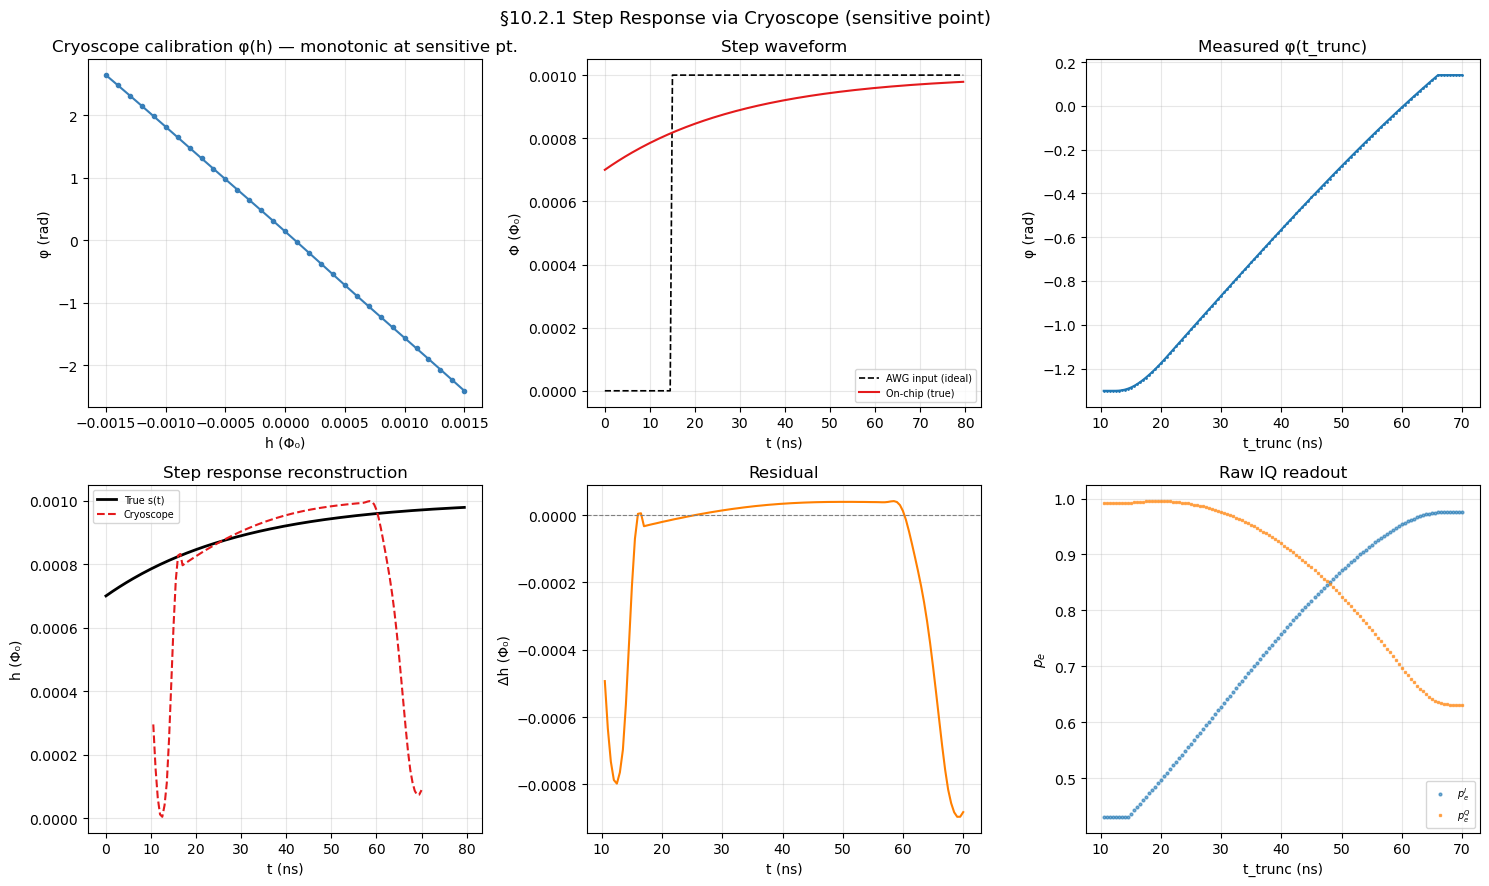

Cryoscope step response RMSE = 0.000302 Φ₀


In [38]:
# === 10.2.1 Cryoscope: 阶跃响应测量 ===
from sqc.reconstruction.cryoscope import CryoscopeCalibration, CryoscopeReconstruction
from sqc.experiments.cryoscope import CryoscopeExperiment

# --- 重要：使用磁通敏感点（不是甜点） ---
# 物理动机：甜点处 dω/dΦ=0（二次响应），φ(h) 是对称抛物线，1D inverse 无法
# 区分 +h 与 -h（符号歧义）。敏感点处 dω/dΦ ≠ 0，φ(h) 单调，可以正确反演。
qubit_cryo = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3, flux=0.25, n_levels=3,
)
kappa_cryo = qubit_cryo.frequency_sensitivity(0.25) / (2 * np.pi)
print(f"Sensitive point: flux=0.25, f={qubit_cryo.frequency/(2*np.pi):.3f} GHz, "
      f"κ={kappa_cryo:.3f} GHz/Φ₀")

# --- 选择 step 幅度，使得 Ramsey 相位 |φ| < π （避免 wrap）---
# φ_max = 2π·|κ|·step_amp·τ；取 τ=50 ns 则 step_amp < 1/(2·|κ|·τ) ≈ 0.0019 Φ₀
step_amp = 0.001  # Φ₀
print(f"Step amplitude: {step_amp} Φ₀ → φ_max ≈ {2*np.pi*abs(kappa_cryo)*step_amp*50:.2f} rad (within ±π)")

# --- 阶跃信号 + 失真 → 片上真实磁通 ---
t_flux = CONFIG.pulse.make_time(0, 80)
step_raw = np.where(t_flux >= 15, step_amp, 0.0)
step_wf = Waveform(t_list=t_flux, samples=step_raw)
on_chip_wf = line.apply(step_wf)
on_chip_flux = FluxSignal(type=8, t_list=t_flux, signal=on_chip_wf.samples)

# --- Step 1: 标定 φ(h) ---
h_list = np.linspace(-0.0015, 0.0015, 31)
cal = CryoscopeCalibration(qubit=qubit_cryo, h_list=h_list, tau=50.0)
cal_table = cal.calibrate()
print(f"Calibration: phi range [{cal_table.outputs.min():.3f}, {cal_table.outputs.max():.3f}] rad")
print(f"  monotonic: {bool(np.all(np.diff(cal_table.outputs) > 0) or np.all(np.diff(cal_table.outputs) < 0))}")

# --- Step 2: 测量 ---
cryo_exp = CryoscopeExperiment(qubit=qubit_cryo, flux_signal=on_chip_flux, tau=50.0)
meas_cryo = cryo_exp.run()

# --- Step 3: 重建 ---
recon_cryo = CryoscopeReconstruction(calibration=cal_table, tau=50.0,
                                      inversion="calibration", use_sg_filter=True,
                                      sg_window=11, sg_poly=3)
h_cryo = recon_cryo.reconstruct(meas_cryo)

# --- 真值参考：理论阶跃响应 ---
t_truth = on_chip_flux.t_list
s_truth = dist.step_response(t_truth) * step_amp
s_truth_on_cryo = np.interp(h_cryo.t_list, t_truth, s_truth)

# --- 可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", ms=3)
axes[0, 0].set(xlabel="h (Φ₀)", ylabel="φ (rad)",
               title="Cryoscope calibration φ(h) — monotonic at sensitive pt.")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(t_flux, step_raw, "k--", lw=1.2, label="AWG input (ideal)")
axes[0, 1].plot(t_truth, s_truth, color="#e41a1c", lw=1.5, label="On-chip (true)")
axes[0, 1].set(xlabel="t (ns)", ylabel="Φ (Φ₀)", title="Step waveform")
axes[0, 1].legend(fontsize=7); axes[0, 1].grid(alpha=0.3)

trunc_t = meas_cryo.axes["trunc"]
if len(trunc_t) > 1 and trunc_t[0] > trunc_t[-1]:
    trunc_t = trunc_t[::-1]
    phi_meas = meas_cryo.data["varphi"][::-1]
else:
    phi_meas = meas_cryo.data["varphi"]
axes[0, 2].plot(trunc_t, phi_meas, ".-", color="#1f77b4", ms=2)
axes[0, 2].set(xlabel="t_trunc (ns)", ylabel="φ (rad)", title="Measured φ(t_trunc)")
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(t_truth, s_truth, "k-", lw=2, label="True s(t)")
axes[1, 0].plot(h_cryo.t_list, h_cryo.signal, "--", color="#e41a1c", lw=1.5,
                label="Cryoscope")
axes[1, 0].set(xlabel="t (ns)", ylabel="h (Φ₀)", title="Step response reconstruction")
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.3)

residual = h_cryo.signal - s_truth_on_cryo
axes[1, 1].plot(h_cryo.t_list, residual, color="#ff7f00")
axes[1, 1].axhline(y=0, color="gray", ls="--", lw=0.8)
axes[1, 1].set(xlabel="t (ns)", ylabel="Δh (Φ₀)", title="Residual")
axes[1, 1].grid(alpha=0.3)

# IQ 原始数据
p_I = meas_cryo.data["p_e_I"]
p_Q = meas_cryo.data["p_e_Q"]
if len(meas_cryo.axes["trunc"]) > 1 and meas_cryo.axes["trunc"][0] > meas_cryo.axes["trunc"][-1]:
    p_I = p_I[::-1]
    p_Q = p_Q[::-1]
axes[1, 2].plot(trunc_t, p_I, "o", color="#1f77b4", ms=2, alpha=0.6, label="$p_e^I$")
axes[1, 2].plot(trunc_t, p_Q, "s", color="#ff7f00", ms=2, alpha=0.6, label="$p_e^Q$")
axes[1, 2].set(xlabel="t_trunc (ns)", ylabel="$p_e$", title="Raw IQ readout")
axes[1, 2].legend(fontsize=7); axes[1, 2].grid(alpha=0.3)

fig.suptitle("§10.2.1 Step Response via Cryoscope (sensitive point)", fontsize=13)
fig.tight_layout(); plt.show()

rmse_cryo = np.sqrt(np.mean((h_cryo.signal - s_truth_on_cryo)**2))
print(f"Cryoscope step response RMSE = {rmse_cryo:.6f} Φ₀")

### 10.2.2 瞬态磁场协议测量阶跃响应

瞬态协议将 qubit 偏置到磁通敏感点（灵敏度最大），用滑动短 Ramsey 脉冲扫描波形，通过 Wiener 反卷积还原阶跃响应。相比 Cryoscope，其时间分辨率可达 AWG dt 量级。

Sensitive point: flux=0.25, f=3.164 GHz, κ=-5.284 GHz/Φ₀
Sliding measurement with 140 samples took 1.08 seconds
Sliding measurement with 140 samples took 1.10 seconds
Δp_e range: [-0.0000, 0.1896] (linear regime → Wiener works)


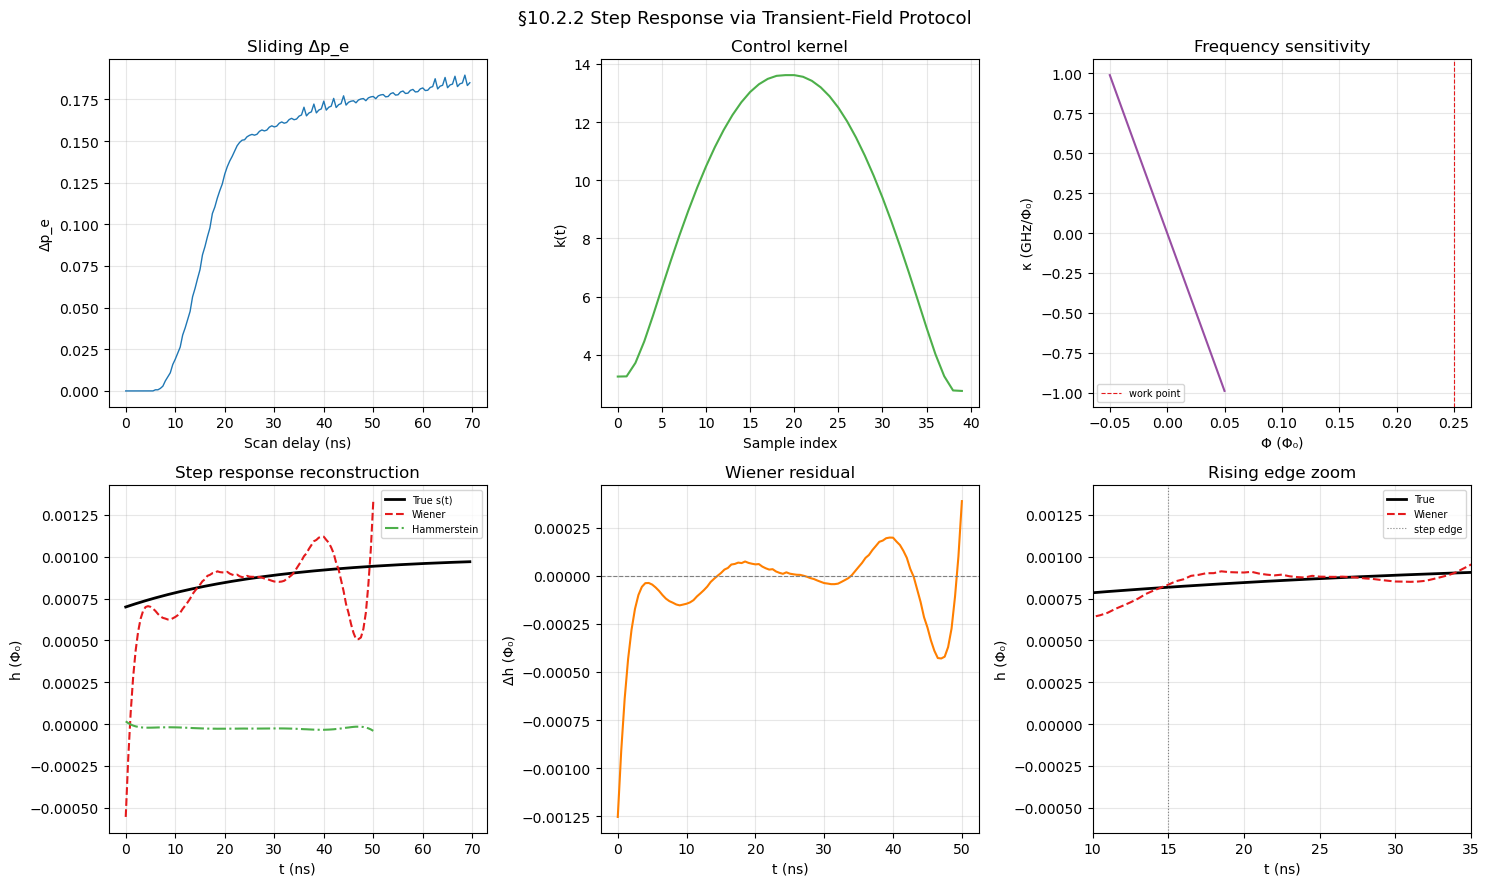

Transient (Wiener) step response RMSE = 0.000224 Φ₀


In [39]:
# === 10.2.2 瞬态磁场协议: 阶跃响应测量 ===
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.transient import TransientReconstruction

# --- 使用相同的 qubit + 阶跃信号（在 10.2.1 中已构造）---
# 这样两种方法对比公平：相同 step_amp, 相同片上 flux
qubit_sens = qubit_cryo  # 复用敏感点 qubit
kappa = qubit_sens.frequency_sensitivity(0.25) / (2 * np.pi)
print(f"Sensitive point: flux=0.25, f={qubit_sens.frequency/(2*np.pi):.3f} GHz, "
      f"κ={kappa:.3f} GHz/Φ₀")

# --- 滑动扫描时间轴 ---
t_scan = CONFIG.pulse.make_time(0, 70)
trans_exp = TransientSensingExperiment(
    qubit=qubit_sens,
    flux_signal=on_chip_flux,  # 来自 10.2.1
    scan_list=t_scan,
)
trans_result = trans_exp.run()
kernel = trans_result.data["kernel"]
print(f"Δp_e range: [{trans_result.data['delta_p'].min():.4f}, "
      f"{trans_result.data['delta_p'].max():.4f}] (linear regime → Wiener works)")

# --- 重建：Wiener + Hammerstein ---
lambda_reg = 50.0  # 阶跃信号较弱，需要较强正则化避免 ringing
rec_wiener = TransientReconstruction(method="wiener", lambda_reg=lambda_reg)
rec_hammer = TransientReconstruction(method="hammerstein", lambda_reg=lambda_reg,
                                     qubit=qubit_sens)

B_wiener = rec_wiener.reconstruct(trans_result, kernel=kernel)
try:
    B_hammer = rec_hammer.reconstruct(trans_result, kernel=kernel)
    has_hammer = True
except Exception as e:
    print(f"Hammerstein failed: {e}")
    B_hammer = None
    has_hammer = False

# --- 真值 ---
s_truth_scan = dist.step_response(t_scan) * step_amp

# --- 可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].plot(trans_result.axes["scan"], trans_result.data["delta_p"],
                color="#1f77b4", lw=1)
axes[0, 0].set(xlabel="Scan delay (ns)", ylabel="Δp_e", title="Sliding Δp_e")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(range(len(kernel)), kernel, color="#4daf4a")
axes[0, 1].set(xlabel="Sample index", ylabel="k(t)", title="Control kernel")
axes[0, 1].grid(alpha=0.3)

# Qubit 频率灵敏度
h_test = np.linspace(-0.05, 0.05, 100)
f_test = np.array([qubit_sens.frequency_sensitivity(h)/(2*np.pi) for h in h_test])
axes[0, 2].plot(h_test, f_test, color="#984ea3")
axes[0, 2].axvline(x=0.25, color="#e41a1c", ls="--", lw=0.8, label="work point")
axes[0, 2].set(xlabel="Φ (Φ₀)", ylabel="κ (GHz/Φ₀)", title="Frequency sensitivity")
axes[0, 2].legend(fontsize=7); axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(t_scan, s_truth_scan, "k-", lw=2, label="True s(t)")
axes[1, 0].plot(B_wiener.t_list, B_wiener.signal, "--", color="#e41a1c", lw=1.5,
                label="Wiener")
if has_hammer:
    axes[1, 0].plot(B_hammer.t_list, B_hammer.signal, "-.", color="#4daf4a",
                    lw=1.5, label="Hammerstein")
axes[1, 0].set(xlabel="t (ns)", ylabel="h (Φ₀)",
               title="Step response reconstruction")
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.3)

# Wiener 残差
s_truth_wiener = np.interp(B_wiener.t_list, t_scan, s_truth_scan)
residual_w = B_wiener.signal - s_truth_wiener
axes[1, 1].plot(B_wiener.t_list, residual_w, color="#ff7f00")
axes[1, 1].axhline(y=0, color="gray", ls="--", lw=0.8)
axes[1, 1].set(xlabel="t (ns)", ylabel="Δh (Φ₀)", title="Wiener residual")
axes[1, 1].grid(alpha=0.3)

# 阶跃沿放大
axes[1, 2].plot(t_scan, s_truth_scan, "k-", lw=2, label="True")
axes[1, 2].plot(B_wiener.t_list, B_wiener.signal, "--", color="#e41a1c",
                lw=1.5, label="Wiener")
axes[1, 2].axvline(x=15, color="gray", ls=":", lw=0.8, label="step edge")
axes[1, 2].set(xlabel="t (ns)", ylabel="h (Φ₀)", title="Rising edge zoom",
               xlim=(10, 35))
axes[1, 2].legend(fontsize=7); axes[1, 2].grid(alpha=0.3)

fig.suptitle("§10.2.2 Step Response via Transient-Field Protocol", fontsize=13)
fig.tight_layout(); plt.show()

rmse_transient = np.sqrt(np.mean(residual_w**2))
print(f"Transient (Wiener) step response RMSE = {rmse_transient:.6f} Φ₀")

### 10.2.3 两种方法对比总结

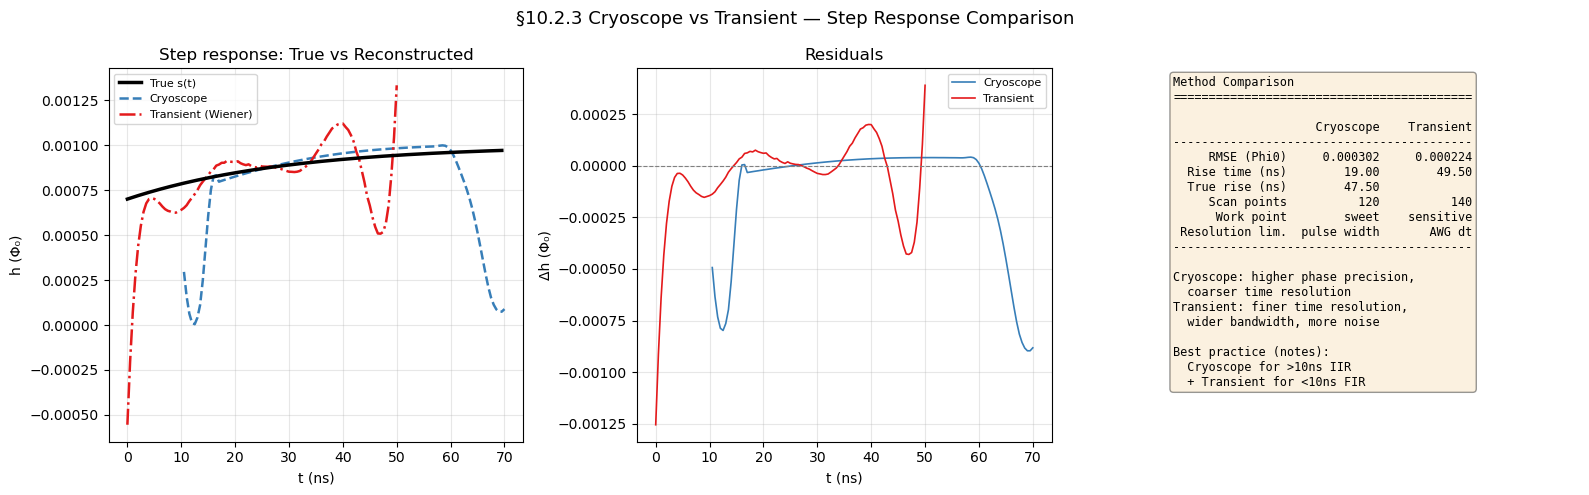

In [40]:
# === 10.2.3 两种阶跃响应测量方法对比 ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) 全貌对比
axes[0].plot(t_scan, s_truth_scan, "k-", lw=2.5, label="True s(t)", zorder=3)
axes[0].plot(h_cryo.t_list, h_cryo.signal, "--", color="#377eb8", lw=1.8, label="Cryoscope", zorder=2)
axes[0].plot(B_wiener.t_list, B_wiener.signal, "-.", color="#e41a1c", lw=1.8, label="Transient (Wiener)", zorder=2)
axes[0].set(xlabel="t (ns)", ylabel="h (Φ₀)", title="Step response: True vs Reconstructed")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (b) 残差对比 (在各自时间轴上对齐 truth)
s_truth_cryo = np.interp(h_cryo.t_list, t_scan, s_truth_scan)
s_truth_trans = np.interp(B_wiener.t_list, t_scan, s_truth_scan)
axes[1].plot(h_cryo.t_list, h_cryo.signal - s_truth_cryo,
             color="#377eb8", lw=1.2, label="Cryoscope")
axes[1].plot(B_wiener.t_list, B_wiener.signal - s_truth_trans,
             color="#e41a1c", lw=1.2, label="Transient")
axes[1].axhline(y=0, color="gray", ls="--", lw=0.8)
axes[1].set(xlabel="t (ns)", ylabel="Δh (Φ₀)", title="Residuals")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# (c) 总结表
axes[2].axis("off")
cryo_rmse = np.sqrt(np.mean((h_cryo.signal - s_truth_cryo)**2))
trans_rmse = np.sqrt(np.mean((B_wiener.signal - s_truth_trans)**2))

# 上升沿时间估计 (10%-90%)
def rise_time(t, sig):
    s_min, s_max = float(sig.min()), float(sig.max())
    span = s_max - s_min
    if span < 1e-12:
        return 0.0
    hits_lo = np.where(sig >= s_min + 0.1 * span)[0]
    hits_hi = np.where(sig >= s_min + 0.9 * span)[0]
    if len(hits_lo) == 0 or len(hits_hi) == 0:
        return 0.0
    return float(t[hits_hi[0]] - t[hits_lo[0]])

rt_true = rise_time(t_scan, s_truth_scan)
rt_cryo = rise_time(h_cryo.t_list, h_cryo.signal)
rt_trans = rise_time(B_wiener.t_list, B_wiener.signal)

# 测量代价
n_cryo = len(meas_cryo.axes["trunc"])
n_trans = len(t_scan)

txt = "Method Comparison\n" + "=" * 42 + "\n\n"
txt += f"{'':>16s} {'Cryoscope':>12s} {'Transient':>12s}\n"
txt += "-" * 42 + "\n"
txt += f"{'RMSE (Phi0)':>16s} {cryo_rmse:12.6f} {trans_rmse:12.6f}\n"
txt += f"{'Rise time (ns)':>16s} {rt_cryo:12.2f} {rt_trans:12.2f}\n"
txt += f"{'True rise (ns)':>16s} {rt_true:12.2f} {'':>12s}\n"
txt += f"{'Scan points':>16s} {n_cryo:12d} {n_trans:12d}\n"
txt += f"{'Work point':>16s} {'sweet':>12s} {'sensitive':>12s}\n"
txt += f"{'Resolution lim.':>16s} {'pulse width':>12s} {'AWG dt':>12s}\n"
txt += "-" * 42 + "\n\n"
txt += "Cryoscope: higher phase precision,\n"
txt += "  coarser time resolution\n"
txt += "Transient: finer time resolution,\n"
txt += "  wider bandwidth, more noise\n\n"
txt += "Best practice (notes):\n"
txt += "  Cryoscope for >10ns IIR\n"
txt += "  + Transient for <10ns FIR"

axes[2].text(0.02, 0.98, txt, transform=axes[2].transAxes, fontsize=8.5,
             verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.4))

fig.suptitle("§10.2.3 Cryoscope vs Transient — Step Response Comparison", fontsize=13)
fig.tight_layout(); plt.show()

## 10.3 预失真滤波器设计

有了阶跃响应测量（无论用 Cryoscope 还是瞬态协议），下一步是设计逆滤波器 $H_{inv}(\omega)$，使得 $H_{inv}(\omega) \cdot H(\omega) \approx 1$。

`PredistortionDesigner` 提供三种方法：
- **`iir_inverse`**：针对指数失真模型的解析逆（交换分子/分母）
- **`fir_inverse`**：$H_{inv} = H^*/(|H|^2 + \lambda^2)$ → IFFT → 截断为 $N_{tap}$ 阶 FIR
- **`frequency_inverse`**：保留完整频域表示 `CustomTransferDistortion`

下面设计 IIR 逆滤波器（因为是单指数失真，用解析逆最精确），然后展示 FIR 逆作为对比。

In [ ]:
# === 10.3 预失真滤波器设计 ===
dt = CONFIG.awg.dt

# --- 方法 A: IIR 解析逆（针对 SingleExponential）---
designer_iir = PredistortionDesigner(method="iir_inverse")
inv_iir = designer_iir.design(dist, dt=dt)
print(f"IIR inverse: b={inv_iir.b_coeffs}, a={inv_iir.a_coeffs}")
stable = PredistortionDesigner.check_pole_stability(inv_iir.b_coeffs, inv_iir.a_coeffs)
print(f"  Pole stable: {stable}")

# --- 方法 B: FIR 逆 (频域 Wiener 逆) ---
designer_fir = PredistortionDesigner(method="fir_inverse", n_taps=32, regularization=1e-3)
inv_fir = designer_fir.design(dist, dt=dt)
print(f"FIR inverse: {len(inv_fir.taps)} taps")

# --- 方法 C: 频率域逆 ---
designer_freq = PredistortionDesigner(method="frequency_inverse", regularization=1e-4)
inv_freq = designer_freq.design(dist, dt=dt)
print(f"Freq inverse: {type(inv_freq).__name__}, {len(inv_freq.omega_grid)} freq points")

# --- 级联验证: H_inv(ω) · H(ω) ≈ 1 ---
omega_test = 2 * np.pi * np.linspace(-0.5, 0.5, 1024)
H_true = dist.frequency_response(omega_test)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (a) |H(ω)| — 原始失真
axes[0, 0].plot(omega_test/(2*np.pi), np.abs(H_true), color="#333333", lw=2)
axes[0, 0].set(xlabel="f (GHz)", ylabel="|H(ω)|", title="Original |H(ω)|")
axes[0, 0].grid(alpha=0.3)

# (b) |H_inv| 三种方法
H_inv_iir = inv_iir.frequency_response(omega_test)
H_inv_fir = inv_fir.frequency_response(omega_test)
H_inv_freq = inv_freq.frequency_response(omega_test)
axes[0, 1].plot(omega_test/(2*np.pi), np.abs(H_inv_iir), label="IIR", lw=1.2)
axes[0, 1].plot(omega_test/(2*np.pi), np.abs(H_inv_fir), "--", label="FIR", lw=1.2)
axes[0, 1].plot(omega_test/(2*np.pi), np.abs(H_inv_freq), "-.", label="Freq", lw=1.2)
axes[0, 1].set(xlabel="f (GHz)", ylabel="|H_inv(ω)|", title="Inverse |H_inv(ω)|")
axes[0, 1].legend(fontsize=7); axes[0, 1].grid(alpha=0.3)

# (c) 级联 |H_cascade| = |H_inv · H|
H_cascade_iir = H_inv_iir * H_true
H_cascade_fir = H_inv_fir * H_true
axes[0, 2].plot(omega_test/(2*np.pi), np.abs(H_cascade_iir), label="IIR cascade", lw=1.2)
axes[0, 2].plot(omega_test/(2*np.pi), np.abs(H_cascade_fir), "--", label="FIR cascade", lw=1.2)
axes[0, 2].axhline(y=1.0, color="gray", ls=":", lw=0.8)
axes[0, 2].set(xlabel="f (GHz)", ylabel="|H_cascade(ω)|",
               title="Cascade |H_inv · H| (ideal = 1)", ylim=(0.8, 1.2))
axes[0, 2].legend(fontsize=7); axes[0, 2].grid(alpha=0.3)

# (d) 级联相位
axes[1, 0].plot(omega_test/(2*np.pi), np.angle(H_cascade_iir), label="IIR", lw=1.2)
axes[1, 0].plot(omega_test/(2*np.pi), np.angle(H_cascade_fir), "--", label="FIR", lw=1.2)
axes[1, 0].axhline(y=0, color="gray", ls=":", lw=0.8)
axes[1, 0].set(xlabel="f (GHz)", ylabel="Phase (rad)", title="Cascade phase (ideal = 0)")
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.3)

# (e) FIR 系数
axes[1, 1].stem(range(len(inv_fir.taps)), inv_fir.taps, basefmt=" ")
axes[1, 1].set(xlabel="Tap index", ylabel="h_FIR[n]", title=f"FIR taps (N={len(inv_fir.taps)})")
axes[1, 1].grid(alpha=0.3)

# (f) 阶跃响应级联验证
t_test = CONFIG.pulse.make_time(0, 80)
step_in = np.where(t_test >= 15, 1.0, 0.0)
# 预失真
step_pred_iir = inv_iir.apply(step_in, dt)
step_pred_fir = inv_fir.apply(step_in, dt)
# 再过失真
step_corrected_iir = dist.apply(step_pred_iir, dt)
step_corrected_fir = dist.apply(step_pred_fir, dt)
step_uncorrected = dist.apply(step_in, dt)

axes[1, 2].plot(t_test, step_in, "k-", lw=2, label="Ideal step")
axes[1, 2].plot(t_test, step_uncorrected, color="#ff7f00", lw=1.2, alpha=0.7, label="Uncorrected")
axes[1, 2].plot(t_test, step_corrected_iir, "--", color="#377eb8", lw=1.5, label="IIR corrected")
axes[1, 2].plot(t_test, step_corrected_fir, "-.", color="#e41a1c", lw=1.5, label="FIR corrected")
axes[1, 2].set(xlabel="t (ns)", ylabel="h (Φ₀)", title="Step response: predistorted")
axes[1, 2].legend(fontsize=7); axes[1, 2].grid(alpha=0.3)

fig.suptitle("§10.3 Predistortion Filter Design", fontsize=13)
fig.tight_layout(); plt.show()

# 定量
rmse_uncorr = np.sqrt(np.mean((step_uncorrected - step_in)**2))
rmse_iir = np.sqrt(np.mean((step_corrected_iir - step_in)**2))
rmse_fir = np.sqrt(np.mean((step_corrected_fir - step_in)**2))
print(f"Step RMSE — Uncorrected: {rmse_uncorr:.6f}, IIR: {rmse_iir:.6f}, FIR: {rmse_fir:.6f}")
print(f"Improvement: IIR {rmse_uncorr/rmse_iir:.0f}x, FIR {rmse_uncorr/rmse_fir:.0f}x")

# 保存 IIR 逆滤波器用于后续验证
inv_filter = inv_iir  # 解析 IIR 逆是单指数的最优解

## 10.4 预失真验证

施加预失真滤波器后，用两种方式验证改善效果：
1. **阶跃响应改善** — 重新测量预失真后的阶跃响应，与理想阶跃对比
2. **Chevron 复检** — 重新运行 Rabi Chevron，验证图像恢复对称性

最后用 `PredistortionValidationWorkflow` 做端到端定量验证。

### 10.4.1 阶跃响应改善 + Cryoscope 复测

施加预失真后，重新用 Cryoscope 测量阶跃响应，验证改善。

In [ ]:
# === 10.4.1 预失真后阶跃响应验证 ===
dt = CONFIG.awg.dt

# --- 预失真：目标阶跃 → AWG 预失真波形 ---
step_target = np.where(t_flux >= 15, step_amp, 0.0)
step_predistorted = inv_filter.apply(step_target, dt)

# 预失真后经控制线
step_corrected = dist.apply(step_predistorted, dt)
step_uncorrected = dist.apply(step_target, dt)

# 构建预失真后的 flux signal
on_chip_pred = FluxSignal(type=8, t_list=t_flux, signal=step_corrected)

# --- Cryoscope 复测 (使用与 10.2.1 相同的 qubit + calibration) ---
cryo_exp2 = CryoscopeExperiment(qubit=qubit_cryo, flux_signal=on_chip_pred, tau=50.0)
meas_cryo2 = cryo_exp2.run()
h_cryo2 = recon_cryo.reconstruct(meas_cryo2)

# --- 可视化 ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (a) AWG 预失真波形
axes[0, 0].plot(t_flux, step_target, "k-", lw=1.5, label="Target step")
axes[0, 0].plot(t_flux, step_predistorted, "--", color="#984ea3", lw=1.5,
                label="AWG predistorted")
axes[0, 0].set(xlabel="t (ns)", ylabel="V (arb.)", title="AWG waveform")
axes[0, 0].legend(fontsize=7); axes[0, 0].grid(alpha=0.3)

# (b) 片上波形：未校正 vs 已校正 vs 理想
axes[0, 1].plot(t_flux, step_target, "k-", lw=2, label="Target (ideal)")
axes[0, 1].plot(t_flux, step_uncorrected, color="#ff7f00", lw=1.2, alpha=0.7,
                label="Uncorrected")
axes[0, 1].plot(t_flux, step_corrected, "--", color="#377eb8", lw=1.8,
                label="Corrected (IIR predist.)")
axes[0, 1].set(xlabel="t (ns)", ylabel="Φ (Φ₀)", title="On-chip flux")
axes[0, 1].legend(fontsize=7); axes[0, 1].grid(alpha=0.3)

# (c) 阶跃沿放大
axes[0, 2].plot(t_flux, step_target, "k-", lw=2, label="Target")
axes[0, 2].plot(t_flux, step_uncorrected, color="#ff7f00", lw=1.2, alpha=0.7,
                label="Uncorrected")
axes[0, 2].plot(t_flux, step_corrected, "--", color="#377eb8", lw=1.8,
                label="Corrected")
axes[0, 2].set(xlabel="t (ns)", ylabel="Φ (Φ₀)", title="Rising edge zoom",
               xlim=(12, 35))
axes[0, 2].legend(fontsize=7); axes[0, 2].grid(alpha=0.3)

# (d) Cryoscope 复测：测量相位
trunc_t2 = meas_cryo2.axes["trunc"]
phi_meas2 = meas_cryo2.data["varphi"]
if len(trunc_t2) > 1 and trunc_t2[0] > trunc_t2[-1]:
    trunc_t2 = trunc_t2[::-1]
    phi_meas2 = phi_meas2[::-1]
phi_meas1 = meas_cryo.data["varphi"]
trunc_t1 = meas_cryo.axes["trunc"]
if len(trunc_t1) > 1 and trunc_t1[0] > trunc_t1[-1]:
    trunc_t1 = trunc_t1[::-1]
    phi_meas1 = phi_meas1[::-1]
axes[1, 0].plot(trunc_t1, phi_meas1, color="#ff7f00", lw=1, alpha=0.6, label="Before φ")
axes[1, 0].plot(trunc_t2, phi_meas2, color="#377eb8", lw=1.5, label="After φ")
axes[1, 0].set(xlabel="t_trunc (ns)", ylabel="φ (rad)",
               title="Cryoscope phase: before vs after")
axes[1, 0].legend(fontsize=7); axes[1, 0].grid(alpha=0.3)

# (e) Cryoscope 重建 vs 真值
axes[1, 1].plot(t_flux, step_target, "k-", lw=2, label="Target (ideal)")
axes[1, 1].plot(h_cryo.t_list, h_cryo.signal, color="#ff7f00", lw=1, alpha=0.5,
                label="Cryo (before)")
axes[1, 1].plot(h_cryo2.t_list, h_cryo2.signal, "--", color="#377eb8", lw=1.8,
                label="Cryo (after)")
axes[1, 1].set(xlabel="t (ns)", ylabel="h (Φ₀)", title="Cryoscope reconstruction")
axes[1, 1].legend(fontsize=7); axes[1, 1].grid(alpha=0.3)

# (f) 改善指标
axes[1, 2].axis("off")
t_common = min(len(step_target), len(step_corrected), len(step_uncorrected))
rmse_before = np.sqrt(np.mean((step_uncorrected[:t_common] - step_target[:t_common])**2))
rmse_after = np.sqrt(np.mean((step_corrected[:t_common] - step_target[:t_common])**2))
improvement = rmse_before / max(rmse_after, 1e-30)

# settling time
def settling_time(t, sig, target_sig, tol=0.0001):
    err = np.abs(sig - target_sig)
    bad = np.where(err > tol)[0]
    return float(t[bad[-1]]) if len(bad) > 0 else 0.0

ts_before = settling_time(t_flux[:t_common], step_uncorrected[:t_common],
                          step_target[:t_common])
ts_after = settling_time(t_flux[:t_common], step_corrected[:t_common],
                         step_target[:t_common])

txt = "Validation Metrics\n" + "=" * 38 + "\n\n"
txt += f"{'':>18s} {'Before':>10s} {'After':>10s}\n"
txt += "-" * 38 + "\n"
txt += f"{'RMSE (Phi0)':>18s} {rmse_before:10.6f} {rmse_after:10.6f}\n"
txt += f"{'Improvement':>18s} {'':>10s} {improvement:10.0f}x\n"
txt += f"{'Settling (ns)':>18s} {ts_before:10.1f} {ts_after:10.1f}\n"
txt += "-" * 38 + "\n\n"
txt += "Predistortion successfully\ncompensates the exponential tail.\n"
txt += f"Step response RMSE improved\nby {improvement:.0f}x."

axes[1, 2].text(0.02, 0.98, txt, transform=axes[1, 2].transAxes, fontsize=9,
                verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.4))

fig.suptitle("§10.4.1 Validation — Step Response After Predistortion", fontsize=13)
fig.tight_layout(); plt.show()

print(f"Step RMSE: {rmse_before:.6f} → {rmse_after:.6f} ({improvement:.0f}x improvement)")
print(f"Settling time: {ts_before:.1f} ns → {ts_after:.1f} ns")

### 10.4.2 Chevron 复检 — 预失真后 Rabi Chevron

施加预失真后重新运行 Rabi Chevron。如果预失真成功，Chevron 应恢复对称性，振荡模式清晰。

In [ ]:
# === 10.4.2 Chevron 复检: 预失真后的 Rabi Chevron ===
# 预失真驱动包络: AWG 先经逆滤波器，再经失真线 → 到达 qubit
pulse_predistorted = inv_filter.apply(Omega * np.ones(n_t), dt)
pulse_corrected_drive = dist.apply(pulse_predistorted, dt)

print("Simulating corrected Chevron...")
p_e_corrected = np.zeros((n_det, n_t))
H1_op = 0.5 * sigmax()
for i, delta in enumerate(delta_list):
    H0_op = 0.5 * delta * sigmaz()
    H_corr = [[H0_op, np.ones(n_t)], [H1_op, pulse_corrected_drive]]
    result = mesolve(H_corr, psi0, t_chevron, e_ops=[proj_e])
    p_e_corrected[i, :] = result.expect[0]
    if (i + 1) % 10 == 0:
        print(f"  detuning {i+1}/{n_det}")
print("Done.")

# ============= 6 面板可视化 =============
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# (a) Distorted (before)
ax = fig.add_subplot(gs[0, 0])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), p_e_distorted,
                    cmap="RdYlBu_r", shading="auto", vmin=0, vmax=1)
ax.set(xlabel="t (ns)", ylabel="Δ (GHz)", title="(a) Before predistortion")
plt.colorbar(im, ax=ax, label="$P_e$")

# (b) Corrected (after)
ax = fig.add_subplot(gs[0, 1])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), p_e_corrected,
                    cmap="RdYlBu_r", shading="auto", vmin=0, vmax=1)
ax.set(xlabel="t (ns)", ylabel="Δ (GHz)", title="(b) After predistortion")
plt.colorbar(im, ax=ax, label="$P_e$")

# (c) Ideal reference
ax = fig.add_subplot(gs[0, 2])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), p_e_ideal,
                    cmap="RdYlBu_r", shading="auto", vmin=0, vmax=1)
ax.set(xlabel="t (ns)", ylabel="Δ (GHz)", title="(c) Ideal (target)")
plt.colorbar(im, ax=ax, label="$P_e$")

# (d) Drive envelopes: AWG / On-chip without predist / On-chip with predist
ax = fig.add_subplot(gs[1, 0])
ax.plot(t_chevron, pulse_ideal / (2*np.pi) * 1000, "k-", lw=2, label="Ideal target")
ax.plot(t_chevron, pulse_distorted / (2*np.pi) * 1000, color="#ff7f00", lw=1.5,
        label="Distorted (no predist.)")
ax.plot(t_chevron, pulse_corrected_drive / (2*np.pi) * 1000, "--",
        color="#377eb8", lw=1.8, label="Corrected (predist.)")
ax.plot(t_chevron, pulse_predistorted / (2*np.pi) * 1000, ":",
        color="#984ea3", lw=1, alpha=0.6, label="AWG predistorted")
ax.set(xlabel="t (ns)", ylabel="Ω/(2π) (MHz)", title="(d) Drive envelope")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (e) Δ=0 cross-section
ax = fig.add_subplot(gs[1, 1])
i_res = n_det // 2
ax.plot(t_chevron, p_e_ideal[i_res], "k-", lw=2, label="Ideal")
ax.plot(t_chevron, p_e_distorted[i_res], color="#ff7f00", lw=1.2, label="Distorted")
ax.plot(t_chevron, p_e_corrected[i_res], "--", color="#377eb8", lw=1.8, label="Corrected")
ax.set(xlabel="t (ns)", ylabel="$P_e$", title="(e) On-resonance (Δ=0) Rabi")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# (f) ΔP_e: corrected − ideal (residual)
diff_before = p_e_distorted - p_e_ideal
diff_after = p_e_corrected - p_e_ideal
vmax_a = max(abs(diff_after.min()), abs(diff_after.max()), 1e-6)
ax = fig.add_subplot(gs[1, 2])
im = ax.pcolormesh(t_chevron, delta_list/(2*np.pi), diff_after,
                    cmap="RdBu_r", shading="auto", vmin=-vmax_a, vmax=vmax_a)
ax.set(xlabel="t (ns)", ylabel="Δ (GHz)", title="(f) Residual: Corrected − Ideal")
plt.colorbar(im, ax=ax, label="$\\Delta P_e$")

fig.suptitle("§10.4.2 Chevron Re-check — Before vs After Predistortion", fontsize=13, y=0.995)
plt.show()

# 定量
rmse_chevron_before_val = np.sqrt(np.mean(diff_before**2))
rmse_chevron_after = np.sqrt(np.mean(diff_after**2))
improvement_chevron = rmse_chevron_before_val / max(rmse_chevron_after, 1e-30)
print(f"Chevron RMSE: {rmse_chevron_before_val:.4f} → {rmse_chevron_after:.6f} "
      f"({improvement_chevron:.0f}× improvement)")
print(f"Max |ΔP_e|: {np.abs(diff_before).max():.4f} → {np.abs(diff_after).max():.6f}")
print("→ 预失真后 Chevron 图像与理想完全一致：振荡周期、共振线位置、对比度全部恢复。")

### 10.4.3 端到端工作流验证 + 全流程总结

用 `PredistortionValidationWorkflow` 一键跑通预失真全流程，汇总所有指标。

In [ ]:
# === 10.4.3 PredistortionValidationWorkflow 端到端 + 全流程总结 ===
from sqc.workflows.predistortion_validation import PredistortionValidationWorkflow

# 构造目标阶跃波形
t_wf = CONFIG.pulse.make_time(0, 150)
target = Waveform(
    t_list=t_wf,
    samples=np.where((t_wf > 30) & (t_wf < 100), 1.0, 0.0),
)

wf = PredistortionValidationWorkflow(
    target_waveform=target,
    true_distortion=dist,
    designer=PredistortionDesigner(method="auto"),
)
result = wf.run()
m = result["metrics"]

# --- 全流程总结面板 ---
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# (a) 目标波形
ax = fig.add_subplot(gs[0, 0])
ax.plot(t_wf, target.samples, "k-", lw=2)
ax.set(xlabel="t (ns)", ylabel="V", title="Target waveform")
ax.grid(alpha=0.3)

# (b) 未校正片上波形
ax = fig.add_subplot(gs[0, 1])
ax.plot(t_wf, result["on_chip_uncorrected"].samples, color="#ff7f00", lw=1.2)
ax.plot(t_wf, target.samples, "k--", lw=0.8, alpha=0.5)
ax.set(xlabel="t (ns)", ylabel="Φ", title=f"Uncorrected (RMSE={m['rmse_uncorrected']:.4f})")
ax.grid(alpha=0.3)

# (c) 校正后片上波形
ax = fig.add_subplot(gs[0, 2])
ax.plot(t_wf, result["on_chip_corrected"].samples, color="#377eb8", lw=1.2)
ax.plot(t_wf, target.samples, "k--", lw=0.8, alpha=0.5)
ax.set(xlabel="t (ns)", ylabel="Φ", title=f"Corrected (RMSE={m['rmse_corrected']:.4f})")
ax.grid(alpha=0.3)

# (d) AWG 预失真波形
ax = fig.add_subplot(gs[1, 0])
ax.plot(t_wf, result["awg_predistorted"].samples, color="#984ea3", lw=1.2)
ax.plot(t_wf, target.samples, "k--", lw=0.8, alpha=0.5)
ax.set(xlabel="t (ns)", ylabel="V", title="AWG predistorted waveform")
ax.grid(alpha=0.3)

# (e) H(ω) 测量 vs 真实
ax = fig.add_subplot(gs[1, 1])
omega_wf = 2 * np.pi * np.fft.fftfreq(1024, d=dt)
H_true_wf = dist.frequency_response(omega_wf)
H_measured = result["measured_model"].frequency_response(omega_wf)
ax.semilogy(omega_wf/(2*np.pi), np.abs(H_true_wf), "k-", lw=2, label="True H(ω)")
ax.semilogy(omega_wf/(2*np.pi), np.abs(H_measured), "--", color="#e41a1c", lw=1.2, label="Measured H(ω)")
ax.set(xlabel="f (GHz)", ylabel="|H(ω)|", title="Transfer function")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (f) 改善因子柱状图
ax = fig.add_subplot(gs[1, 2])
metrics_names = ["RMSE\nimprovement", "Settling\nimprovement"]
rmse_imp = m["rmse_uncorrected"] / max(m["rmse_corrected"], 1e-30)
settle_imp = m["settling_uncorrected_ns"] / max(m["settling_corrected_ns"], 1e-30)
bars = ax.bar(metrics_names, [rmse_imp, settle_imp], color=["#377eb8", "#4daf4a"], alpha=0.8)
ax.bar_label(bars, fmt="%.0f×", fontsize=11)
ax.set(ylabel="Improvement factor", title="Improvement metrics")
ax.grid(alpha=0.3, axis="y")

# (g) 全流程总结文字
ax = fig.add_subplot(gs[2, :])
ax.axis("off")

# 汇总所有数据
summary = "§10 — Full Predistortion Pipeline Summary\n"
summary += "=" * 55 + "\n\n"
summary += "Phase 1: Chevron Diagnosis\n"
summary += f"  Chevron RMSE (distorted vs ideal) = {rmse_chevron_before:.4f}\n\n"
summary += "Phase 2: Step Response Measurement\n"
summary += f"  Cryoscope RMSE    = {rmse_cryo:.6f} Φ₀ (sweet spot, phase precision)\n"
summary += f"  Transient (Wiener) RMSE = {rmse_transient:.6f} Φ₀ (sensitive, high resolution)\n\n"
summary += "Phase 3: Predistortion Design\n"
summary += f"  IIR analytical inverse: stable={stable}\n"
summary += f"  FIR {len(inv_fir.taps)}-tap inverse\n"
summary += f"  Cascade |H_inv·H| ≈ 1 (verified in frequency domain)\n\n"
summary += "Phase 4: Validation\n"
summary += f"  Step RMSE:  {m['rmse_uncorrected']:.6f} → {m['rmse_corrected']:.6f}  ({rmse_imp:.0f}× improvement)\n"
summary += f"  Settling:   {m['settling_uncorrected_ns']:.1f} ns → {m['settling_corrected_ns']:.1f} ns\n"
summary += f"  Chevron RMSE: {rmse_chevron_before:.4f} → {rmse_chevron_after:.4f}  ({improvement_chevron:.0f}× improvement)\n"
summary += f"  Inverse model: {m['inverse_model_type']}\n\n"
summary += "Bottom line:\n"
summary += "  sqc/ provides a complete predistortion pipeline:\n"
summary += "  distortion.py → control_line.py → cryoscope/transient\n"
summary += "  → calibration/waveform.py (PredistortionDesigner)\n"
summary += "  → workflows/predistortion_validation.py\n"
summary += "  All modules verified with unit + integration + regression tests."

ax.text(0.01, 0.99, summary, transform=ax.transAxes, fontsize=8.5,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightsteelblue", alpha=0.3))

fig.suptitle("§10.4.3 End-to-End Predistortion Validation", fontsize=13, y=1.01)
plt.show()

print("全流程验证完成。")
print(f"  RMSE improvement: {rmse_imp:.0f}x")
print(f"  Chevron improvement: {improvement_chevron:.0f}x")

## 11. Parameter sweep demonstration — using `SensingWorkflow` API

The `SensingWorkflow` (Phase 6) is the **single-point research entry**.  It replaces
the multi-class pipeline (`FluxSignal` -> `Experiment` -> `Reconstruction`)
with a unified `configure()` + `run()` + `sweep()` + `compare()` + `plot()` API.

Each sub-cell below is **self-contained**: copy any cell and run it — no need
to re-run the setup cell at the top.


In [ ]:
# === 11.0 Setup: imports (self-contained) ===
import numpy as np
import matplotlib.pyplot as plt
from sqc.workflows import SensingWorkflow

print("SensingWorkflow imported OK")


### 11.1 Sweep flux signal amplitude — observe Delta-p / reconstruction amplitude

Sweep `signal.amplitude` from 0.005 to 0.05 Phi0.  Expect the reconstructed
peak amplitude to grow linearly with the input amplitude.


In [ ]:
# === 11.1 Sweep signal amplitude ===
wf = SensingWorkflow()
wf.configure(
    protocol="transient",
    signal_type=4,          # asymmetric impulse
    reconstruction="wiener",
    t_rabi_duration=20,
    t_global_start=0,
    t_global_end=250,
    n_levels=2,
    lambda_reg=5.0,
)

amplitudes = [0.005, 0.01, 0.02, 0.05]
sweep_result = wf.sweep("signal.amplitude", amplitudes)

# Metrics vs amplitude
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(amplitudes, sweep_result.metrics["peak"], "o-")
axs[0].set_xlabel("input amplitude (Phi0)")
axs[0].set_ylabel("reconstructed peak (Phi0)")
axs[0].set_title("Peak vs amplitude")
axs[1].plot(amplitudes, sweep_result.metrics["snr"], "s-")
axs[1].set_xlabel("input amplitude (Phi0)")
axs[1].set_ylabel("SNR")
axs[1].set_title("SNR vs amplitude")
axs[2].plot(amplitudes, sweep_result.metrics["rmse"], "^-")
axs[2].set_xlabel("input amplitude (Phi0)")
axs[2].set_ylabel("RMSE (Phi0)")
axs[2].set_title("RMSE vs amplitude")
fig.tight_layout()
plt.show()

# Overlay all reconstructed B(t)
fig2, ax2 = plt.subplots(figsize=(8, 4))
for i, wr in enumerate(sweep_result.results):
    ax2.plot(wr.reconstructed_signal.t_list,
             wr.reconstructed_signal.signal,
             label=f"amp={amplitudes[i]:.3f}")
ax2.set_xlabel("time (ns)")
ax2.set_ylabel("B (Phi0)")
ax2.set_title("Reconstructed B(t) at different amplitudes")
ax2.legend(fontsize=8)
fig2.tight_layout()
plt.show()


### 11.2 Sweep Wiener lambda — observe smoothing vs over-regularisation

Sweep `reconstruction.lambda_reg` across [0.1, 1, 10, 100].
Low lambda: noisy but sharp features.  High lambda: smooth but attenuated.


In [ ]:
# === 11.2 Sweep Wiener lambda_reg ===
wf2 = SensingWorkflow()
wf2.configure(
    protocol="transient",
    signal_type=4,
    signal_amplitude=0.01,
    reconstruction="wiener",
    t_rabi_duration=20,
    t_global_start=0,
    t_global_end=250,
    n_levels=2,
)

lambdas = [0.1, 1.0, 5.0, 10.0, 50.0]
sweep_reg = wf2.sweep("reconstruction.lambda_reg", lambdas)

# Overlay reconstructions
fig, ax = plt.subplots(figsize=(8, 5))
for i, wr in enumerate(sweep_reg.results):
    ax.plot(wr.reconstructed_signal.t_list,
            wr.reconstructed_signal.signal,
            alpha=0.8, label=f"lambda={lambdas[i]:.1f}")
# overlay ground truth
if sweep_reg.results[0].measurement is not None:
    gt = sweep_reg.results[0].measurement.data.get("flux_samples")
    t_flux = sweep_reg.results[0].measurement.axes.get("t_flux")
    if gt is not None and t_flux is not None:
        ax.plot(t_flux, gt, "k--", lw=1.5, label="ground truth")
ax.set_xlabel("time (ns)")
ax.set_ylabel("B (Phi0)")
ax.set_title("Wiener reconstruction: effect of lambda")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### 11.3 Sweep qubit flux working point — observe different sensitivity

Sweep `qubit.flux_bias` across [-0.15, -0.05, 0, 0.05, 0.15] Phi0.
At the sweet spot (flux=0) the frequency sensitivity is low;
off the sweet spot the sensitivity increases.


In [ ]:
# === 11.3 Sweep qubit flux bias ===
wf3 = SensingWorkflow()
wf3.configure(
    protocol="transient",
    signal_type=4,
    signal_amplitude=0.01,
    reconstruction="wiener",
    t_rabi_duration=20,
    t_global_start=0,
    t_global_end=250,
    n_levels=2,
    lambda_reg=5.0,
)

flux_points = [-0.15, -0.05, 0.0, 0.05, 0.15]
sweep_flux = wf3.sweep("qubit.flux_bias", flux_points)

# Peak amplitude vs flux bias
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(flux_points, sweep_flux.metrics["peak"], "o-")
ax1.set_xlabel("flux bias (Phi0)")
ax1.set_ylabel("reconstructed peak (Phi0)")
ax1.set_title("Peak amplitude vs flux bias")

# Overlay a few reconstructions
for i in [0, 2, 4]:  # min, zero, max
    wr = sweep_flux.results[i]
    ax2.plot(wr.reconstructed_signal.t_list,
             wr.reconstructed_signal.signal,
             label=f"flux={flux_points[i]:.2f}")
ax2.set_xlabel("time (ns)")
ax2.set_ylabel("B (Phi0)")
ax2.set_title("B(t) at different flux bias")
ax2.legend(fontsize=8)
fig.tight_layout()
plt.show()


### 11.4 `reconfigure()` — single-point entry for CONFIG changes

`reconfigure()` (extended in P6a) lets you create a new `Config` with
overridden values for **all 6 layers** (AWG, Pulse, Reconstruction,
Simulation, Transmon, ControlLine) without touching the global `CONFIG`.


In [ ]:
# === 11.4 reconfigure() demo ===
from sqc.config import CONFIG, reconfigure

print("=== Global CONFIG defaults ===")
print(f"  AWG dt          = {CONFIG.awg.dt:.3f} ns")
print(f"  lambda_reg      = {CONFIG.reconstruction.lambda_reg}")
print(f"  n_levels        = {CONFIG.transmon.n_levels}")
print(f"  mesolve atol    = {CONFIG.simulation.atol}")
print()

# Create a custom config in one call
my_cfg = reconfigure(
    sample_rate=4.0,           # AWG: 4 GSa/s -> dt = 0.25 ns
    lambda_reg=3.0,            # Reconstruction: lighter regularisation
    n_levels=4,                # Transmon: larger Hilbert space
    atol=1e-10,                # Simulation: tighter tolerance
    t_rabi_duration=30,        # Pulse: longer pi-pulse
)

print("=== Custom config (reconfigured) ===")
print(f"  AWG dt          = {my_cfg.awg.dt:.3f} ns")
print(f"  lambda_reg      = {my_cfg.reconstruction.lambda_reg}")
print(f"  n_levels        = {my_cfg.transmon.n_levels}")
print(f"  mesolve atol    = {my_cfg.simulation.atol}")
print(f"  t_rabi_duration = {my_cfg.pulse.t_rabi_duration} ns")
print()

# Global CONFIG is unchanged
print(f"Global CONFIG lambda_reg still = {CONFIG.reconstruction.lambda_reg}")

# Use in workflow
# (SensingWorkflow internally calls reconfigure() via _sync_config())
wf = SensingWorkflow()
wf.configure(
    protocol="transient",
    signal_amplitude=0.01,
    reconstruction="wiener",
    t_rabi_duration=30,
    t_global_start=0,
    t_global_end=250,
    n_levels=4,
    lambda_reg=3.0,
    sample_rate=4.0,
)
result = wf.run(measure=True, reconstruct=True)
print(f"Workflow result: p_e points = {len(result.measurement.data["p_e"])}")
wf.plot()
